In [130]:
%load_ext autoreload
%autoreload 2


from paper_utils import *


def get_arg_df(configs):
    # now add the config args to both dfs
    arg_df = []
    for wandbid, config in configs.items():
        try:
            arg_df.append([wandbid] + [config[arg.replace('.', '_')] for arg in args])
        except:
            arg_df.append([wandbid] + [config[arg] for arg in args])
        
    arg_df = pd.DataFrame(arg_df, columns=['wandbid'] + ['c.' + arg for arg in args])

    unique_cols = []
    for column in arg_df.columns[1:]:
        if column in ['name', 'c.slurmid', 'c.state']:
            continue
        if len(arg_df[column].unique()) > 1:
            unique_cols += [column]
    uniq_name = 'UNIQ-' + '-'.join(unique_cols)
    arg_df[uniq_name] = arg_df.apply(
        lambda x: '-'.join([str(x[col]) for col in unique_cols]),
        axis=1)


    return arg_df, uniq_name, unique_cols

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [714]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')


In [715]:
# args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']

args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']


configs = {}

for run in api_runs[:100]:
    # finished = run.state == 'finished'
    # lot = 'run_25_nov' in run.description
    # if finished:

    configs[run.id] = run.config
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]

In [716]:
tmp_arg_df, _, _ = get_arg_df(configs)

with pd.option_context('display.max_rows', None):
    tmp = tmp_arg_df.set_index('c.metric').loc['llm_gpt-4'].set_index('c.state').loc['finished']
    display(tmp) #need display to show the dataframe when using with in jupyter

,wandbid,c.slurmid,c.dataset,c.model_name,c.entailment_model,UNIQ-c.dataset-c.model_name-c.metric-c.entailment_model
c.state,,,,,,
finished,1pkhq510,173011,trivia_qa,Llama-2-13b-chat,gpt-3.5,trivia_qa-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,csqqhso7,173013,svamp,Llama-2-13b-chat,gpt-3.5,svamp-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,b8mbxsg4,173015,bioasq,falcon-7b-instruct,gpt-3.5,bioasq-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,0xauxgy4,173012,squad,Llama-2-13b-chat,gpt-3.5,squad-Llama-2-13b-chat-llm_gpt-4-gpt-3.5
finished,mzx43pb8,173018,svamp,falcon-7b-instruct,gpt-3.5,svamp-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,yctf458k,173019,nq,falcon-7b-instruct,gpt-3.5,nq-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,0ssvgj9k,173016,trivia_qa,falcon-7b-instruct,gpt-3.5,trivia_qa-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,6nas983b,173017,squad,falcon-7b-instruct,gpt-3.5,squad-falcon-7b-instruct-llm_gpt-4-gpt-3.5
finished,spgwcck1,173014,nq,Llama-2-13b-chat,gpt-3.5,nq-Llama-2-13b-chat-llm_gpt-4-gpt-3.5


Sweep over models and datasets.

* For large llama, have ablation over entailment model and metric.
* Some falcon runs failed due to rare error

In [ ]:
# new runs llama13b and falcon7b
waiting = {
    '1pkhq510': 'trivia_qa-Llama-2-13b-chat',
    'csqqhso7': 'svamp-Llama-2-13b-chat',  # finished
    'b8mbxsg4': 'bioasq-falcon-7b-instruct',	
    '0xauxgy4': 'squad-Llama-2-13b-chat',
    'mzx43pb8': 'svamp-falcon-7b-instruct',	
    'yctf458k': 'nq-falcon-7b-instruct',
    '0ssvgj9k': 'trivia_qa-falcon-7b-instruct',
    '6nas983b': 'squad-falcon-7b-instruct',
    'spgwcck1': 'nq-Llama-2-13b-chat',
    'm5kf4xrf': 'bioasq-Llama-2-13b-chat',
}

In [637]:
runs = {
    'fmqxf9ie': 'bioasq-Llama-2-70b-chat', # g144xlp2
    'grar15m5': 'bioasq-Llama-2-7b-chat',
    'nbcamoof': 'bioasq-falcon-40b-instruct',
    'm56crr5d': 'bioasq-Mistral-7B-Instruct-v0.1',

    'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
    '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
    'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
    'kfnome0a': 'trivia_qa-Mistral-7B-Instruct-v0.1',
    
    'nvgkz80j': 'squad-Llama-2-70b-chat',
    'pp7d12fm': 'squad-Llama-2-7b-chat',
    'a4nah729': 'squad-falcon-40b-instruct',  # i26x8noh
    'nlk5ysql': 'squad-Mistral-7B-Instruct-v0.1',

    'tph6z33j': 'svamp-Llama-2-70b-chat-8bit',
    'zw3hnj0b': 'svamp-Llama-2-7b-chat-8bit',
    'mz7dlrvt': 'svamp-falcon-40b-instruct',
    'klza56qe': 'svamp-Mistral-7B-Instruct-v0.1',

    'qpp3a3m3': 'nq-Llama-2-70b-chat-8bit',
    '86mu0ogq': 'nq-Llama-2-7b-chat-8bit',
    'ab1d15w8': 'nq-falcon-40b-instruct',
    '34huu9mg': 'nq-Mistral-7B-Instruct-v0.1',
}


# raise "i've cancelled two runs after the generate stage to free up gpus for other runs! compute_uncertainty does not need gpus anymore"
# 172454
# sbatch --cpus-per-task=8 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --entailment_model=gpt-3.5 --eval_wandb_runid=g144xlp2
# sbatch --cpus-per-task=8 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --entailment_model=gpt-3.5 --eval_wandb_runid=i26x8noh



In [641]:
args = ['state', 'slurmid', 'dataset', 'model_name', 'metric', 'entailment_model']

configs = {}
for run in runs:
    run = api.run(f'goatml/semantic_uncertainty/{run}')
    cfg = run.config

    if eval := cfg.get('eval_wandb_runid'):
        print(f'Warning: blindly taking generate_answers cfg from {eval} instead of compute_uncertainty cfg for {run}')
        cfg = api.run(f'goatml/semantic_uncertainty/{eval}').config
        
    configs[run.id] = cfg
    configs[run.id]['state'] = run.state
    configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]

arg_df, uniq_name, unique_cols = get_arg_df(configs)
arg_df['c.model_name'] = arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])
arg_df

,wandbid,c.state,c.slurmid,c.dataset,c.model_name,c.metric,c.entailment_model,UNIQ-c.dataset-c.model_name
0,fmqxf9ie,finished,172454,bioasq,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-70b-chat
1,grar15m5,finished,171895,bioasq,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,bioasq-Llama-2-7b-chat
2,nbcamoof,finished,171885,bioasq,falcon-40b-instruct,llm_gpt-4,gpt-3.5,bioasq-falcon-40b-instruct
3,m56crr5d,finished,172443,bioasq,Mistral-7B-Instruct-v0.1,llm_gpt-4,gpt-3.5,bioasq-Mistral-7B-Instruct-v0.1
4,abx2s4ve,finished,171898,trivia_qa,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-70b-chat
5,64gkizzd,finished,171900,trivia_qa,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,trivia_qa-Llama-2-7b-chat
6,pfvp6gbb,finished,171914,trivia_qa,falcon-40b-instruct,llm_gpt-4,gpt-3.5,trivia_qa-falcon-40b-instruct
7,kfnome0a,finished,172444,trivia_qa,Mistral-7B-Instruct-v0.1,llm_gpt-4,gpt-3.5,trivia_qa-Mistral-7B-Instruct-v0.1
8,nvgkz80j,finished,171899,squad,Llama-2-70b-chat,llm_gpt-4,gpt-3.5,squad-Llama-2-70b-chat
9,pp7d12fm,finished,171901,squad,Llama-2-7b-chat,llm_gpt-4,gpt-3.5,squad-Llama-2-7b-chat


In [642]:
for value in ['c.state', 'wandbid', 'c.slurmid']:
    display(arg_df.pivot(index='c.dataset', columns='c.model_name', values=value))

c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,finished,finished,finished,finished
nq,finished,finished,finished,finished
squad,finished,finished,finished,finished
svamp,finished,finished,finished,finished
trivia_qa,finished,finished,finished,finished


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,fmqxf9ie,grar15m5,m56crr5d,nbcamoof
nq,qpp3a3m3,86mu0ogq,34huu9mg,ab1d15w8
squad,nvgkz80j,pp7d12fm,nlk5ysql,a4nah729
svamp,tph6z33j,zw3hnj0b,klza56qe,mz7dlrvt
trivia_qa,abx2s4ve,64gkizzd,kfnome0a,pfvp6gbb


c.model_name,Llama-2-70b-chat,Llama-2-7b-chat,Mistral-7B-Instruct-v0.1,falcon-40b-instruct
c.dataset,,,,
bioasq,172454,171895,172443,171885
nq,172442,172627,172630,172508
squad,171899,171901,172445,172455
svamp,172441,172470,172629,172495
trivia_qa,171898,171900,172444,171914


In [341]:
# compare configs between models (same dataset):

for groupby in (['c.dataset', 'c.model_name']):
    print(80 * 'x')
    print(f'Groupby {groupby}')
    
    for dataset, gdf in arg_df.groupby(groupby):
        print(80 * '-')
        print(f'{groupby}: {dataset}')
    
        wandb_ids = gdf.wandbid.values
        base, other = wandb_ids[0], wandb_ids[1:]
    
        name = lambda x: ' '.join(arg_df.set_index('wandbid').loc[x][['c.dataset', 'c.model_name']])
        cfg = deepcopy(configs)
        cfg[base].pop('slurmid')
        cfg[base].pop('state')
        for o in other:
            cfg[o].pop('slurmid')
            cfg[o].pop('state')
            print(f'{base} / {name(base)} vs {o} / {name(o)}')
            print(DeepDiff(cfg[base], cfg[o]))
        

xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
Groupby c.dataset
--------------------------------------------------------------------------------
c.dataset: bioasq
fmqxf9ie / bioasq Llama-2-70b-chat vs grar15m5 / bioasq Llama-2-7b-chat
{'values_changed': {"root['model_name']": {'new_value': 'Llama-2-7b-chat', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 7, 'old_value': 6}}}
fmqxf9ie / bioasq Llama-2-70b-chat vs nbcamoof / bioasq falcon-40b-instruct
{'values_changed': {"root['model_name']": {'new_value': 'falcon-40b-instruct', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 2, 'old_value': 6}}}
fmqxf9ie / bioasq Llama-2-70b-chat vs m56crr5d / bioasq Mistral-7B-Instruct-v0.1
{'values_changed': {"root['model_name']": {'new_value': 'Mistral-7B-Instruct-v0.1', 'old_value': 'Llama-2-70b-chat'}, "root['p_true_num_fewshot']": {'new_value': 2, 'old_value': 6}}}
--------------------------------------

Runs look coherent within each other!

(use_context deos not matter for bioasq!)

Last thing that's needed to check: how do they compare against my previous 'almost perfect' runs?

In [54]:
# expected differences: 15 gens, llm_metric, gpt4_entailment
# old generate answers trivia_qa
DeepDiff(api.run('goatml/semantic_uncertainty/1gxo9oef').config, configs['abx2s4ve'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 10, 'old_value': 5}}}

In [55]:
# generate answers squad
DeepDiff(api.run('goatml/semantic_uncertainty/uvfbxm6d').config, configs['nvgkz80j'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 5, 'old_value': 2}}}

In [56]:
# generate answers bioasq
DeepDiff(api.run('goatml/semantic_uncertainty/dqtye228').config, configs['g144xlp2'])

{'dictionary_item_added': [root['random_seed'], root['recompute_accuracy'], root['compute_accuracy_at_all_temps'], root['state'], root['wandbid'], root['slurmid']],
 'dictionary_item_removed': [root['is_ood_eval']],
 'values_changed': {"root['metric']": {'new_value': 'llm_gpt-4',
   'old_value': 'llm'},
  "root['model_name']": {'new_value': 'Llama-2-70b-chat',
   'old_value': 'Llama-2-70b-chat-8bit'},
  "root['num_generations']": {'new_value': 10, 'old_value': 15},
  "root['entailment_model']": {'new_value': 'gpt-3.5', 'old_value': 'gpt-4'},
  "root['p_true_num_fewshot']": {'new_value': 6, 'old_value': 2}}}

In [409]:
runs = {k: runs[k] for k in runs if arg_df.set_index('wandbid').loc[k]['c.state'] == 'finished'}
runs

{'fmqxf9ie': 'bioasq-Llama-2-70b-chat',
 'grar15m5': 'bioasq-Llama-2-7b-chat',
 'nbcamoof': 'bioasq-falcon-40b-instruct',
 'm56crr5d': 'bioasq-Mistral-7B-Instruct-v0.1',
 'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
 '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
 'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
 'kfnome0a': 'trivia_qa-Mistral-7B-Instruct-v0.1',
 'nvgkz80j': 'squad-Llama-2-70b-chat',
 'pp7d12fm': 'squad-Llama-2-7b-chat',
 'a4nah729': 'squad-falcon-40b-instruct',
 'nlk5ysql': 'squad-Mistral-7B-Instruct-v0.1',
 'tph6z33j': 'svamp-Llama-2-70b-chat-8bit',
 'zw3hnj0b': 'svamp-Llama-2-7b-chat-8bit',
 'mz7dlrvt': 'svamp-falcon-40b-instruct',
 'klza56qe': 'svamp-Mistral-7B-Instruct-v0.1',
 'qpp3a3m3': 'nq-Llama-2-70b-chat-8bit',
 'ab1d15w8': 'nq-falcon-40b-instruct',
 '34huu9mg': 'nq-Mistral-7B-Instruct-v0.1'}

In [ ]:
# final set of runs before addinv svamp/nq/mistral
# {'fmqxf9ie': 'bioasq-Llama-2-70b-chat',
#  'grar15m5': 'bioasq-Llama-2-7b-chat',
#  'nbcamoof': 'bioasq-falcon-40b-instruct',
#  'abx2s4ve': 'trivia_qa-Llama-2-70b-chat',
#  '64gkizzd': 'trivia_qa-Llama-2-7b-chat',
#  'pfvp6gbb': 'trivia_qa-falcon-40b-instruct',
#  'nvgkz80j': 'squad-Llama-2-70b-chat',
#  'pp7d12fm': 'squad-Llama-2-7b-chat',
#  'a4nah729': 'squad-falcon-40b-instruct'}


In [643]:
configs = {k: configs[k] for k in runs}

In [644]:
# all_results = {}
for wandb_id in runs:
    if wandb_id not in all_results:
        all_results[wandb_id], _ = restore_file(wandb_id)

model,bioasq,nq,squad,svamp,trivia_qa
dataset,,,,,
Llama-2-70b-chat,0.6400,NaN,0.4225,NaN,0.8725
Llama-2-70b-chat-8bit,NaN,0.6075,NaN,0.690000,NaN
Llama-2-7b-chat,0.5425,NaN,0.3425,NaN,0.7400
Llama-2-7b-chat-8bit,NaN,0.5075,NaN,0.416667,NaN
Mistral-7B-Instruct-v0.1,0.4950,0.3800,0.2975,0.506667,0.6350
falcon-40b-instruct,0.6025,0.5825,0.3700,0.563333,0.7950


Text(0, 0.5, 'accuracy')

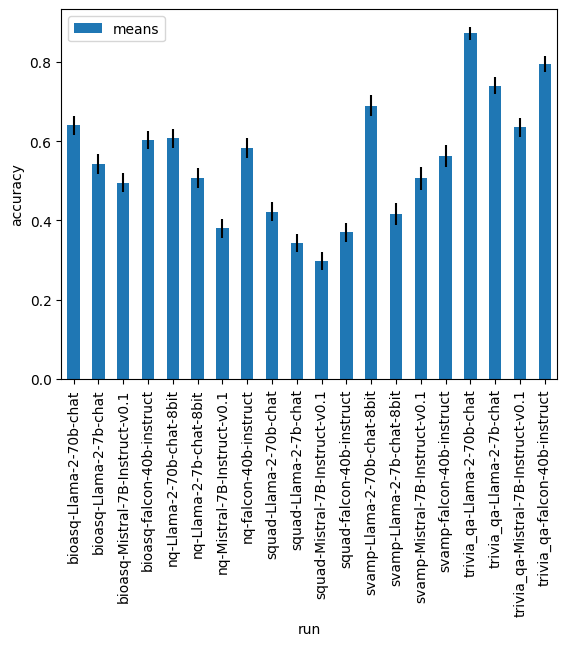

In [645]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)


Text(0, 0.5, 'accuracy')

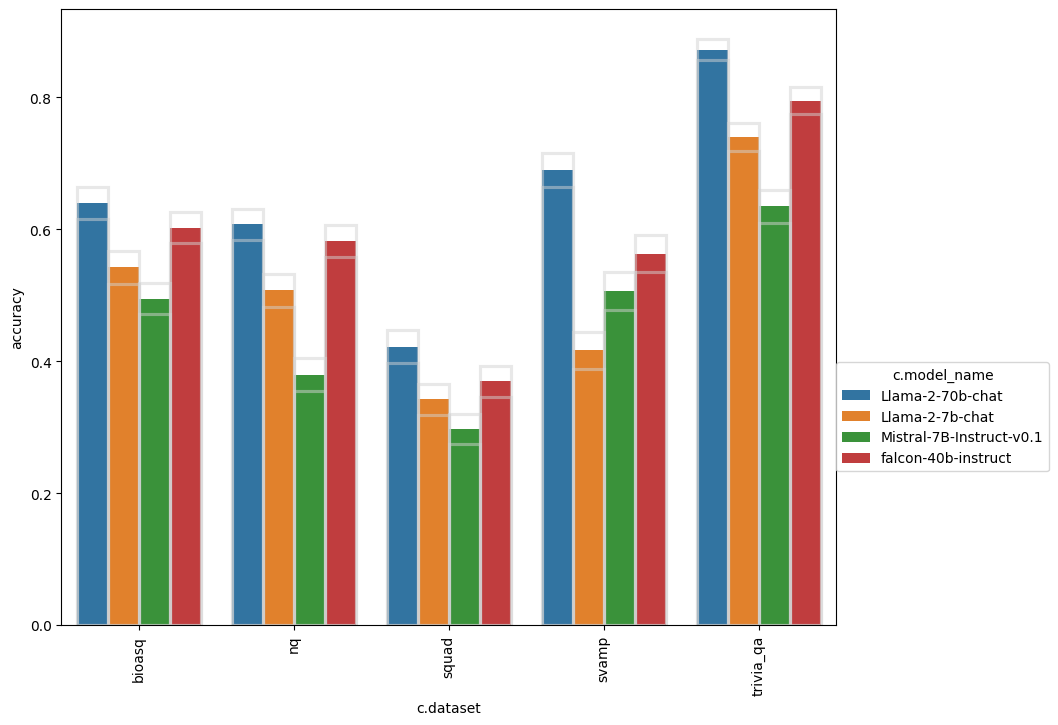

In [646]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf.set_index('method').loc['accuracy'], metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)


In [703]:
# load ood runs for p_ik

pik_runs = {
 'ueysytnh': 'falcon-40b-instruct-svamp-nq',
 'si8o1o3o': 'falcon-40b-instruct-svamp-squad',
 'itt028az': 'falcon-40b-instruct-bioasq-svamp',
 'jimxzgwm': 'falcon-40b-instruct-squad-svamp',
 '8qx4w6pu': 'falcon-40b-instruct-bioasq-squad',
 'szxwvi88': 'falcon-40b-instruct-svamp-bioasq',
 '70v00ze7': 'falcon-40b-instruct-bioasq-nq',
 'gnbhhmbp': 'falcon-40b-instruct-squad-nq',
 'vkrfbq14': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 'e7u6a42p': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 '2c6skk6g': 'falcon-40b-instruct-squad-trivia_qa',
 'wqk3twti': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'sk7xx6a9': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 '86xnaea5': 'Mistral-7B-Instruct-v0.1-bioasq-svamp',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 '5ytf3m50': 'falcon-40b-instruct-squad-bioasq',
 'g7w0saqf': 'Mistral-7B-Instruct-v0.1-trivia_qa-nq',
 '78ubflxu': 'Mistral-7B-Instruct-v0.1-bioasq-nq',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'bqhpmgd5': 'Mistral-7B-Instruct-v0.1-svamp-trivia_qa',
 '5auzcurn': 'Llama-2-70b-chat-trivia_qa-svamp',
 'ix8o3ar9': 'Llama-2-7b-chat-trivia_qa-svamp',
 'xw2oxw14': 'Mistral-7B-Instruct-v0.1-svamp-squad',
 'k2y3iypk': 'falcon-40b-instruct-bioasq-trivia_qa',
 'lzwbjj0u': 'Mistral-7B-Instruct-v0.1-squad-svamp',
 'ektr1wx1': 'Llama-2-70b-chat-trivia_qa-squad',
 's2b3dq5z': 'Llama-2-7b-chat-trivia_qa-squad',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'tojydb0d': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'r5jrwa0p': 'Llama-2-70b-chat-trivia_qa-nq',
 '28is5g4g': 'Mistral-7B-Instruct-v0.1-bioasq-squad',
 'sd6mwmt4': 'Mistral-7B-Instruct-v0.1-squad-trivia_qa',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 'qmb1uu6c': 'Llama-2-7b-chat-svamp-bioasq',
 'akbz2zit': 'Mistral-7B-Instruct-v0.1-squad-nq',
 'iztfq74f': 'Llama-2-70b-chat-trivia_qa-bioasq',
 '22n8akov': 'Llama-2-7b-chat-trivia_qa-bioasq',
 'vik61pbd': 'Llama-2-70b-chat-squad-trivia_qa',
 'v1uuwmni': 'Llama-2-7b-chat-svamp-trivia_qa',
 '64mwf45o': 'Mistral-7B-Instruct-v0.1-svamp-nq',
 'vasvluw9': 'Mistral-7B-Instruct-v0.1-bioasq-trivia_qa',
 'mj98zcis': 'Llama-2-7b-chat-svamp-squad',
 '1pcia04j': 'Llama-2-7b-chat-bioasq-squad',
 '5bumj7c2': 'Llama-2-70b-chat-squad-svamp',
 'p9cad6z3': 'Llama-2-7b-chat-squad-trivia_qa',
 'b4mm06ws': 'Llama-2-70b-chat-svamp-bioasq',
 '588kp7t1': 'falcon-40b-instruct-trivia_qa-bioasq',
 'h473y96f': 'Llama-2-70b-chat-squad-nq',
 'ue0gu578': 'Llama-2-7b-chat-squad-svamp',
 'j6mc86id': 'Llama-2-70b-chat-svamp-trivia_qa',
 '39iaj5ss': 'falcon-40b-instruct-svamp-trivia_qa',
 't39a8www': 'Llama-2-70b-chat-squad-bioasq',
 'pbk4bb3v': 'Llama-2-7b-chat-squad-bioasq',
 'ltjjp3jv': 'falcon-40b-instruct-trivia_qa-squad',
 'jij6xvq6': 'Llama-2-70b-chat-svamp-squad',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'bh9uaw62': 'Llama-2-7b-chat-bioasq-svamp',
 'wazba7ok': 'falcon-40b-instruct-trivia_qa-svamp',
 '6rty54ha': 'Llama-2-70b-chat-bioasq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 'e0imxyab': 'Llama-2-70b-chat-bioasq-squad',
 '77h3tvmd': 'Llama-2-70b-chat-svamp-nq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'bvpw98ih': 'Llama-2-7b-chat-bioasq-trivia_qa',
 'rvvamd9u': 'falcon-40b-instruct-trivia_qa-nq',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad',
 'ig4qamip': 'Llama-2-70b-chat-bioasq-trivia_qa',
 'fc4j2r3i': 'Llama-2-70b-chat-bioasq-nq',
 'ljcrh54n': 'Llama-2-7b-chat-nq-bioasq',
 'jgc2thy5': 'Llama-2-7b-chat-nq-squad',
 'lciwu77a': 'Llama-2-7b-chat-nq-trivia_qa',
 'hu8cexu0': 'Llama-2-7b-chat-nq-svamp',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad'
}

# pik_results = {}
for wandb_id in pik_runs:
    print(wandb_id, list(pik_runs.keys()).index(wandb_id), len(pik_runs))
    if wandb_id not in pik_results:
        pik_results[wandb_id], _ = restore_file(wandb_id)


import pickle
with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_sentence.pkl', 'wb') as f:
    pickle.dump([pik_runs, pik_results], f)

# with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short.pkl', 'rb') as f:
#     pik_runs, pik_results = pickle.load(f)



ueysytnh 0 76
si8o1o3o 1 76
itt028az 2 76
jimxzgwm 3 76
8qx4w6pu 4 76
szxwvi88 5 76
70v00ze7 6 76
gnbhhmbp 7 76
vkrfbq14 8 76
xnwy93zh 9 76
e7u6a42p 10 76
2c6skk6g 11 76
wqk3twti 12 76
0929rm33 13 76
sk7xx6a9 14 76
86xnaea5 15 76
wa4xw7dn 16 76
5ytf3m50 17 76
g7w0saqf 18 76
78ubflxu 19 76
jehdmd18 20 76
64rh8qyb 21 76
bqhpmgd5 22 76
5auzcurn 23 76
ix8o3ar9 24 76
xw2oxw14 25 76
k2y3iypk 26 76
lzwbjj0u 27 76
ektr1wx1 28 76
s2b3dq5z 29 76
g0563a58 30 76
tojydb0d 31 76
c8p7ona4 32 76
r5jrwa0p 33 76
28is5g4g 34 76
sd6mwmt4 35 76
50kln4yq 36 76
qmb1uu6c 37 76
akbz2zit 38 76
iztfq74f 39 76
22n8akov 40 76
vik61pbd 41 76
v1uuwmni 42 76
64mwf45o 43 76
vasvluw9 44 76
mj98zcis 45 76
1pcia04j 46 76
5bumj7c2 47 76
p9cad6z3 48 76
b4mm06ws 49 76
588kp7t1 50 76
h473y96f 51 76
ue0gu578 52 76
j6mc86id 53 76
39iaj5ss 54 76
t39a8www 55 76
pbk4bb3v 56 76
ltjjp3jv 57 76
jij6xvq6 58 76
5dxgi7l4 59 76
bh9uaw62 60 76
wazba7ok 61 76
6rty54ha 62 76
yqefd5tw 63 76
e0imxyab 64 76
77h3tvmd 65 76
7mkmiodg 66 76
bvpw9

In [704]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(pik_runs, all_results=pik_results)
pik_all_runs['c.dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-2])
pik_all_runs['c.ood_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-1])
pik_all_runs['c.model_name'] = pik_all_runs.run.map(lambda x: '-'.join(x.split('-')[:-2]))
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['method_real'] = pik_all_runs['method'] + ' ' + pik_all_runs['c.ood_dataset']
pik_all_runs['method'] = 'p_ik_ood'


model,Llama,Mistral,falcon
dataset,,,
2-70b-chat-bioasq-nq,0.6400,NaN,NaN
2-70b-chat-bioasq-squad,0.6400,NaN,NaN
2-70b-chat-bioasq-svamp,0.6400,NaN,NaN
2-70b-chat-bioasq-trivia_qa,0.6400,NaN,NaN
2-70b-chat-nq-bioasq,0.6075,NaN,NaN
...,...,...,...
7B-Instruct-v0.1-svamp-trivia_qa,NaN,0.506667,NaN
7B-Instruct-v0.1-trivia_qa-bioasq,NaN,0.635000,NaN
7B-Instruct-v0.1-trivia_qa-nq,NaN,0.635000,NaN


/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


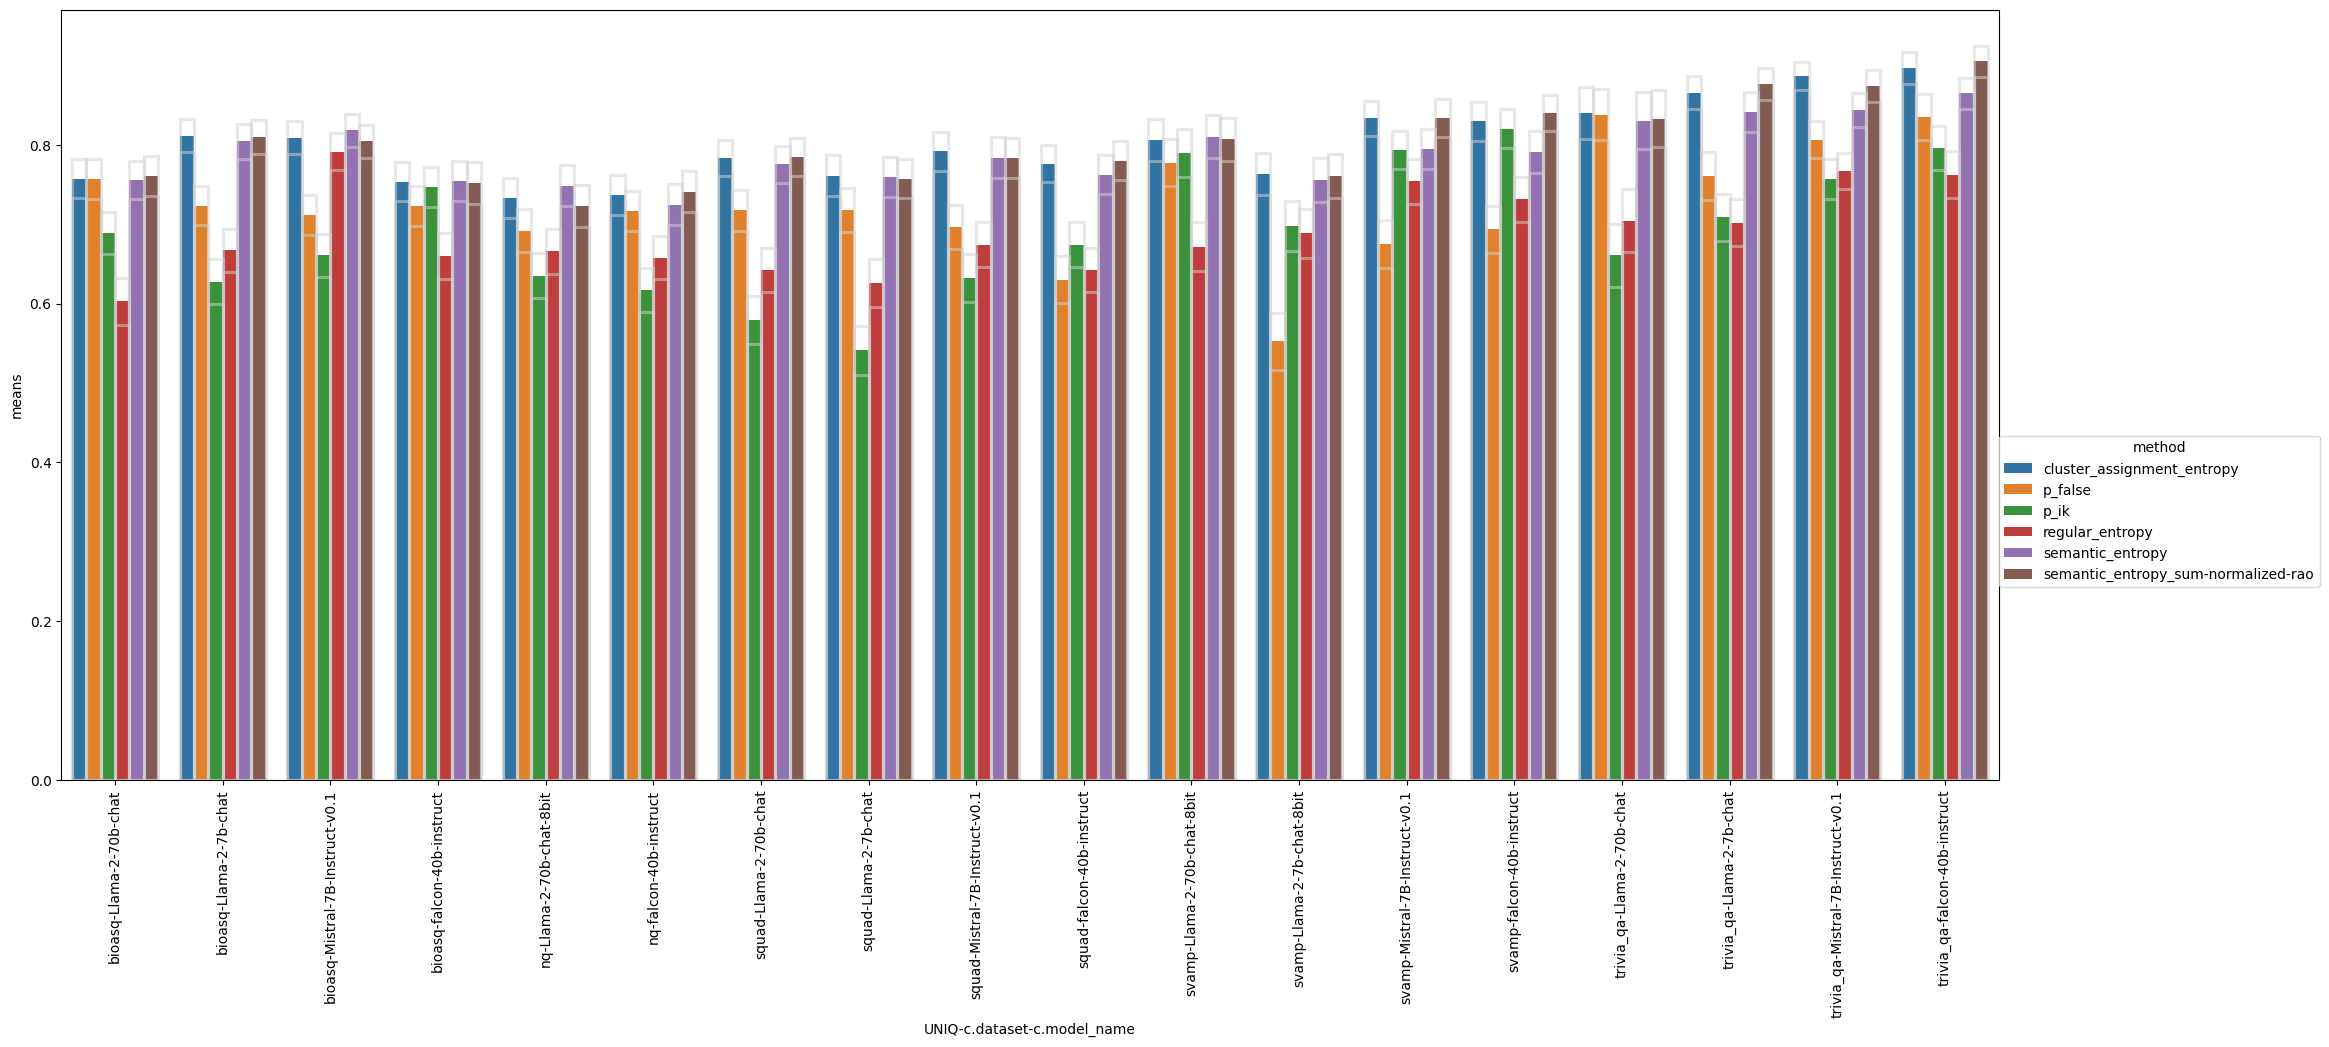

In [398]:

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']
# main_methods = ['regular_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao']


plot_grouped(
    all_runs.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
    metric='means', x=uniq_name, hue='method',
    figsize=(25, 10)
)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

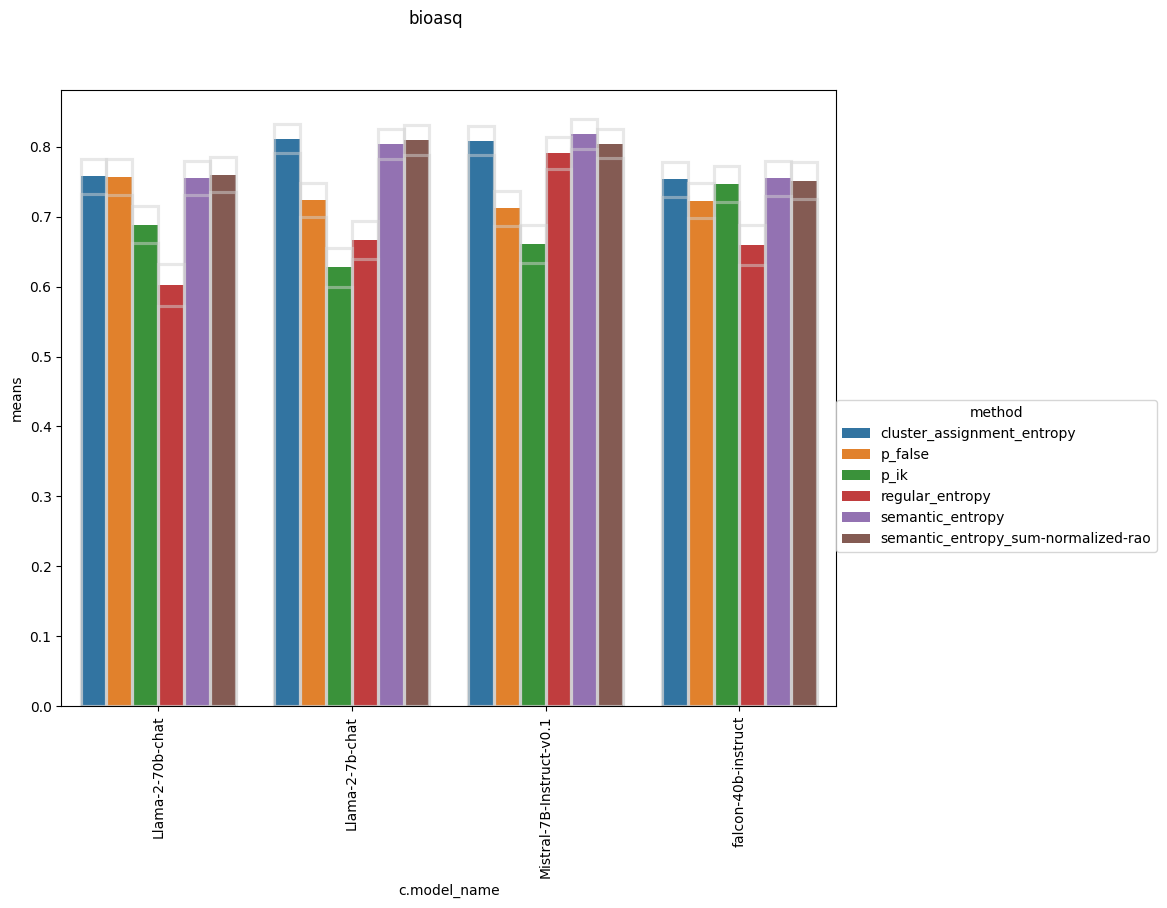

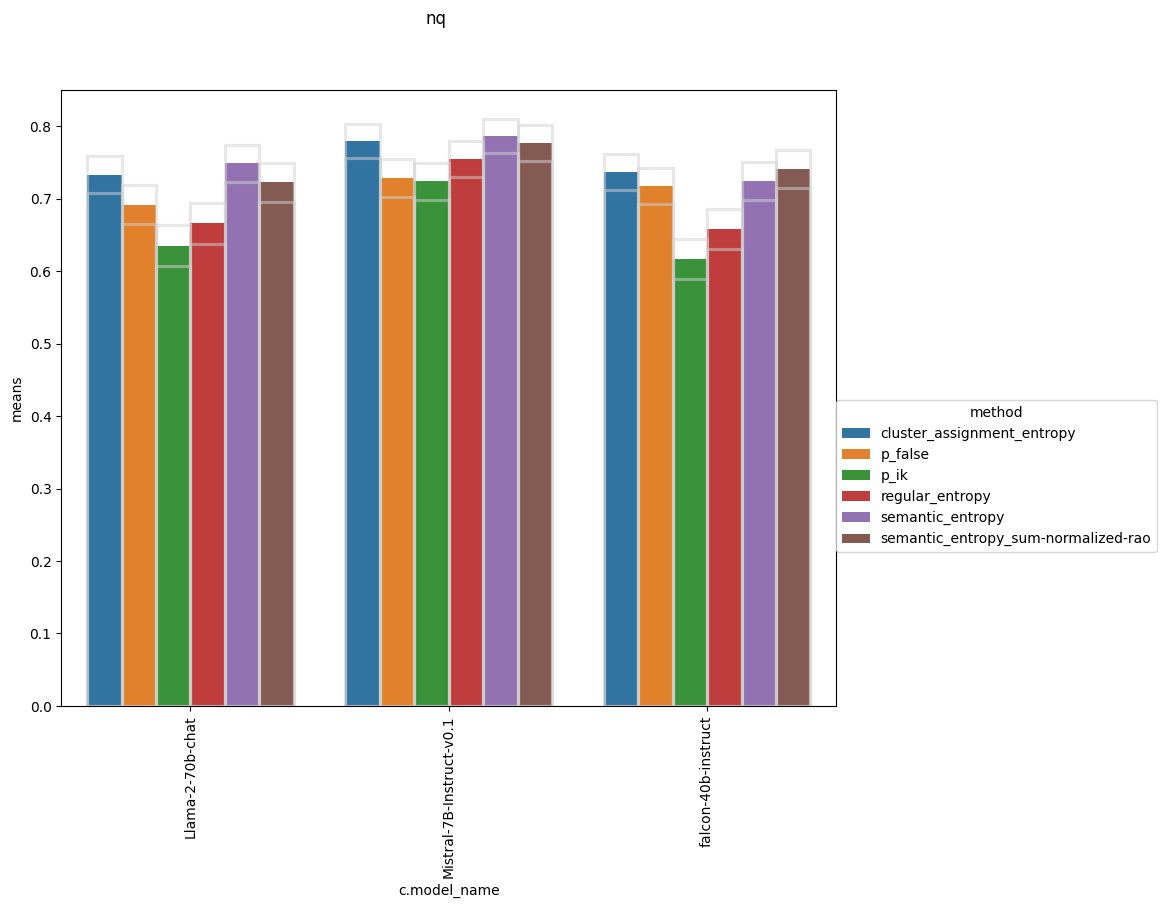

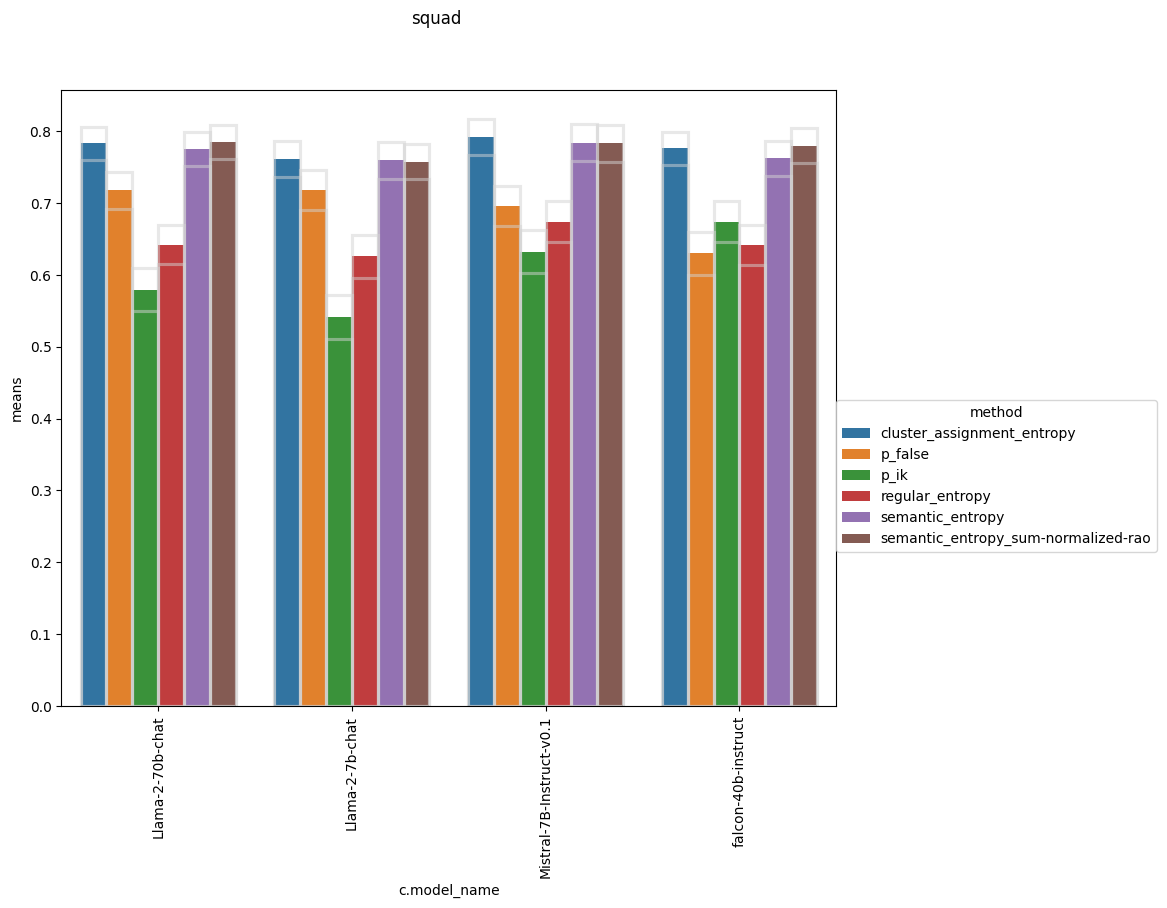

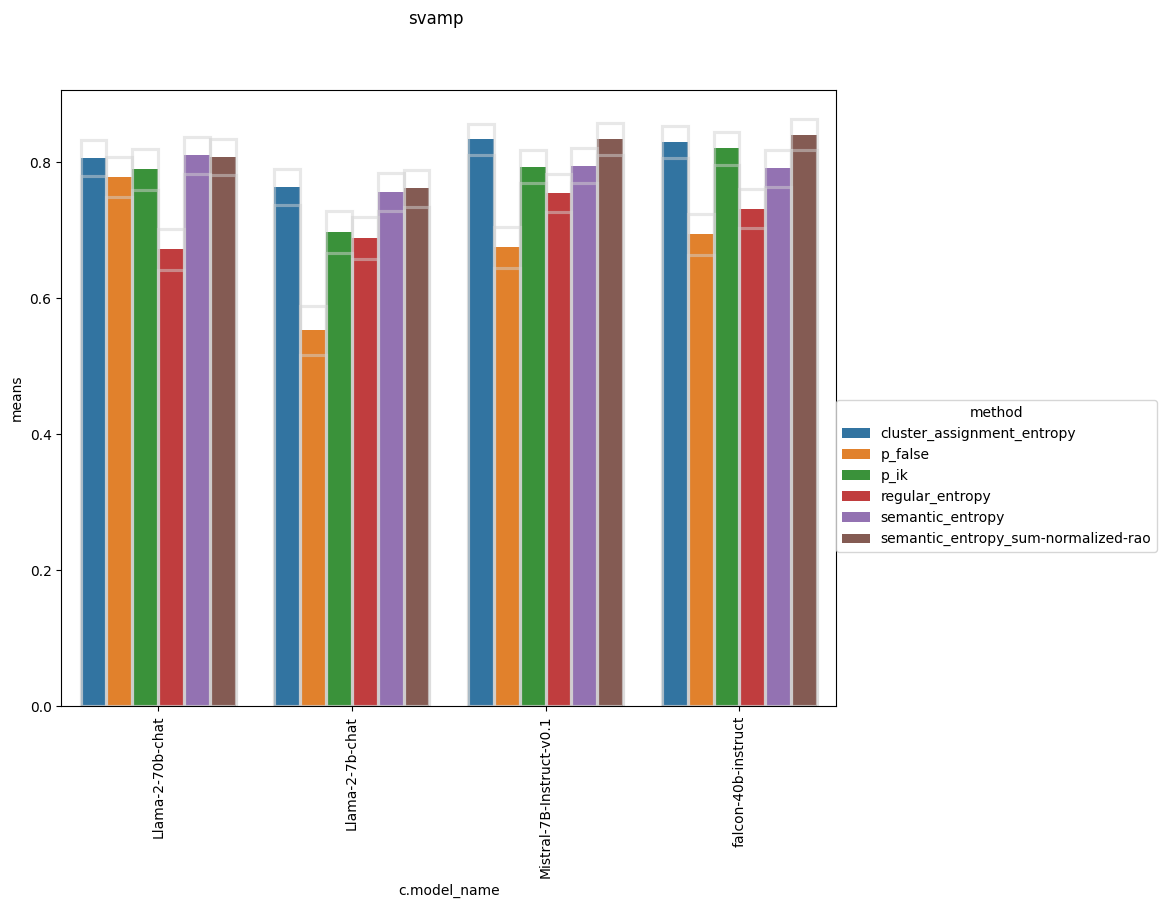

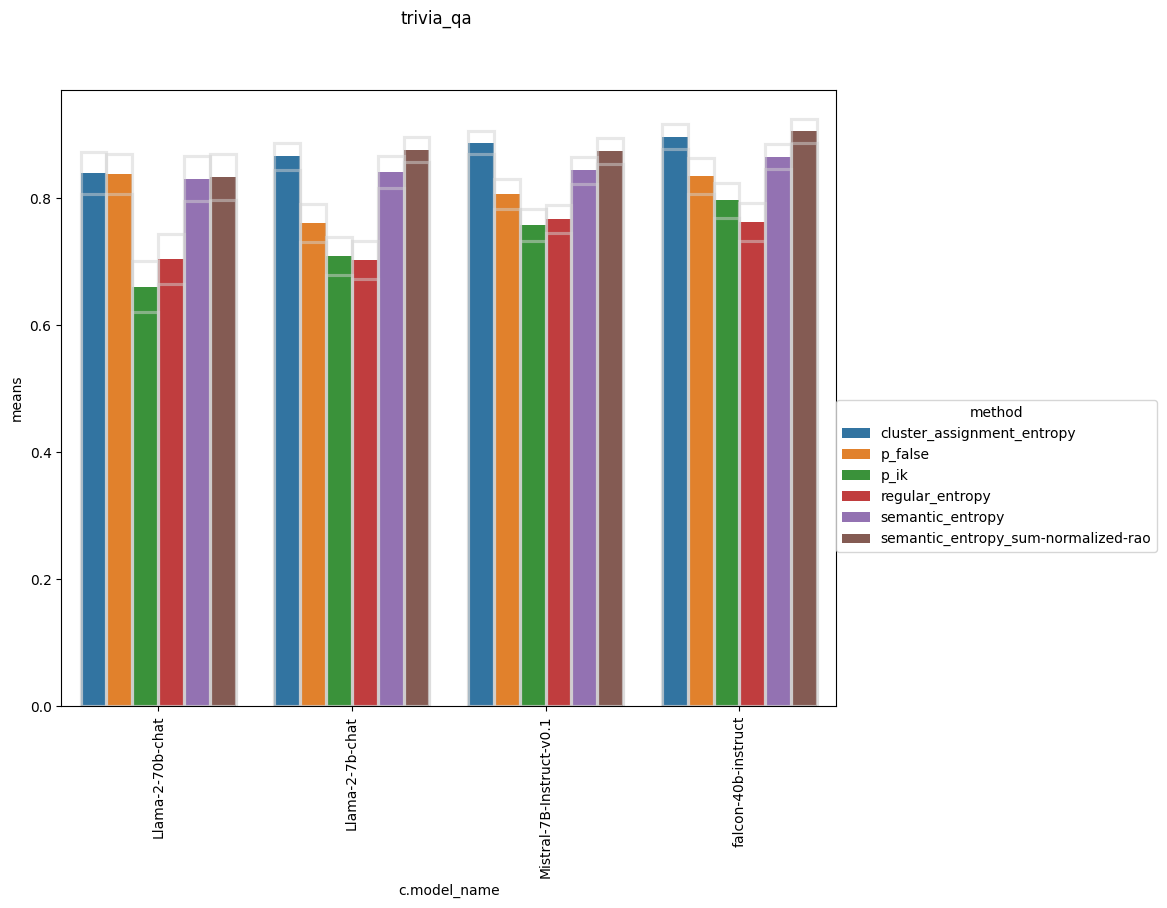

In [487]:
for dataset, gdf in all_runs.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods].reset_index(),
        metric='means', x='c.model_name', hue='method',
    )
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

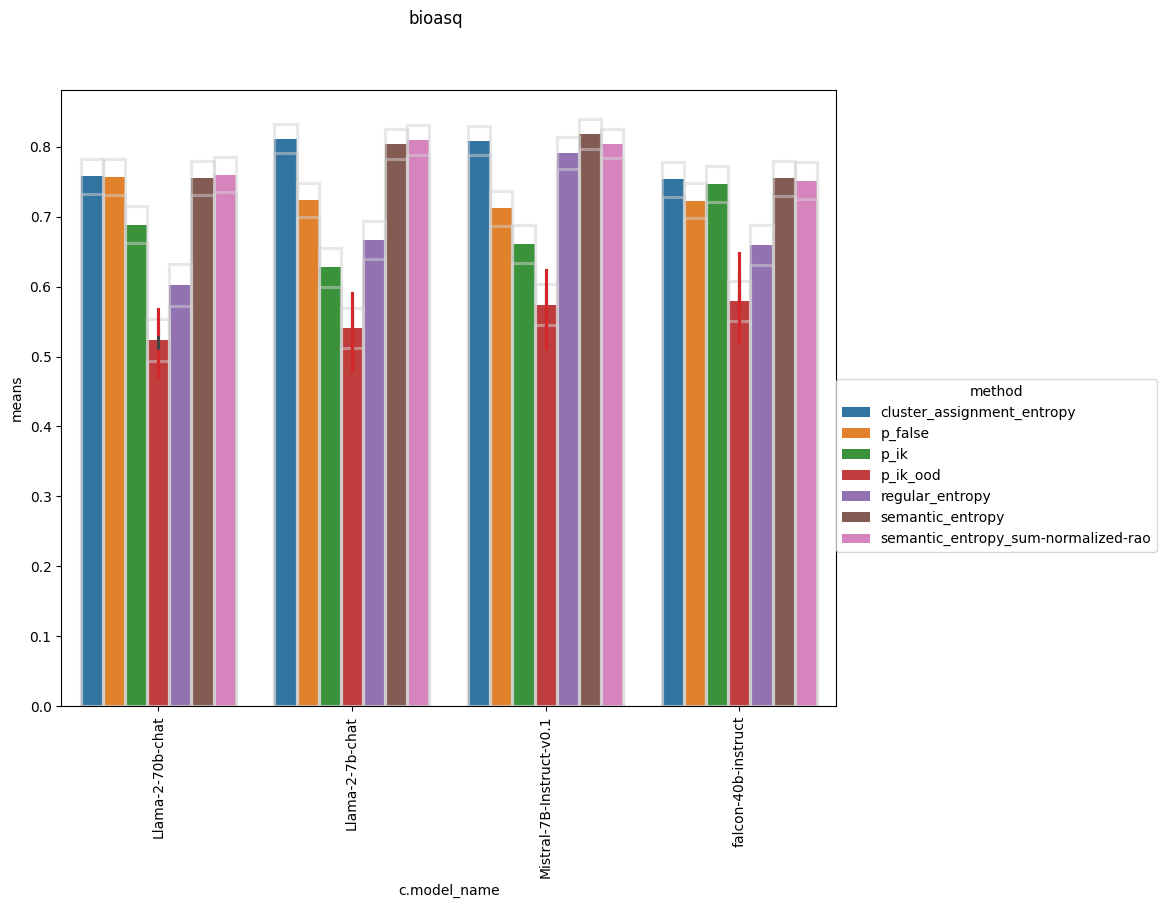

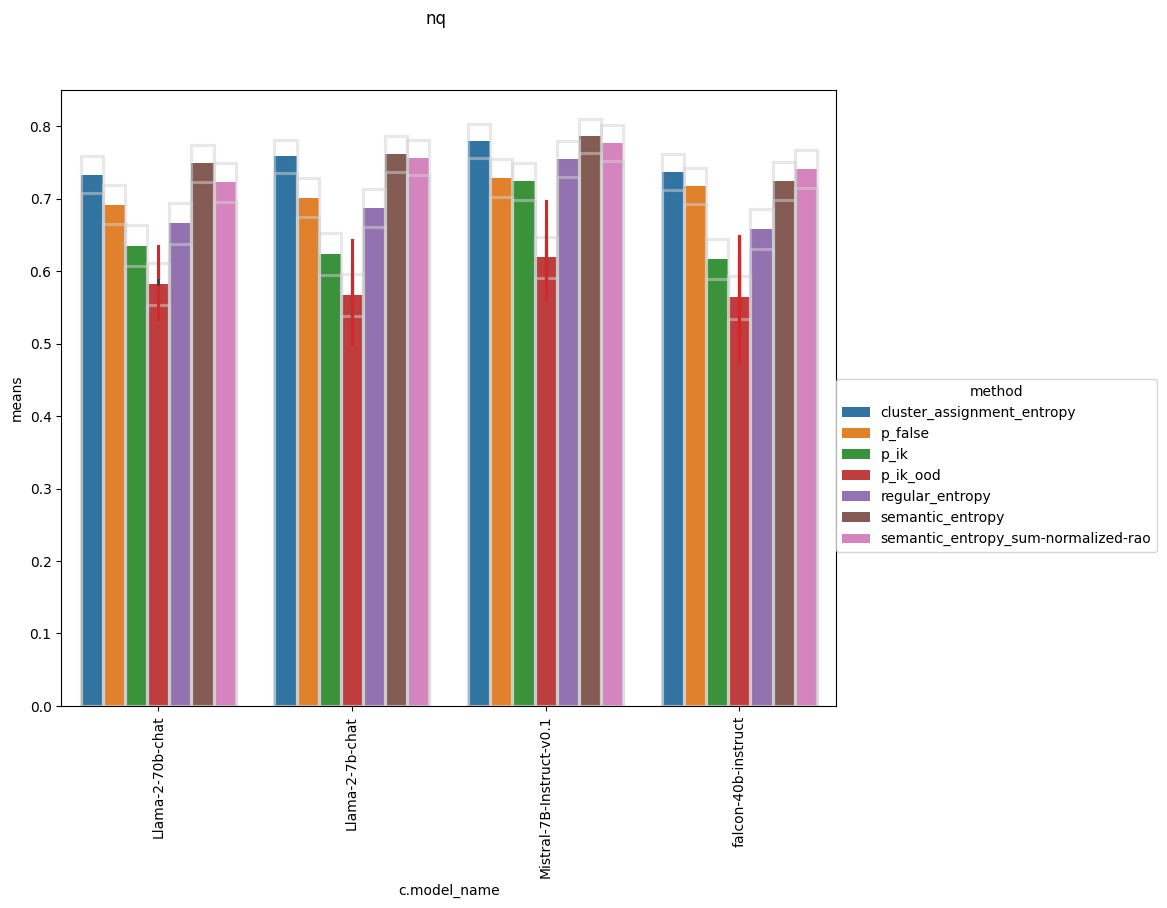

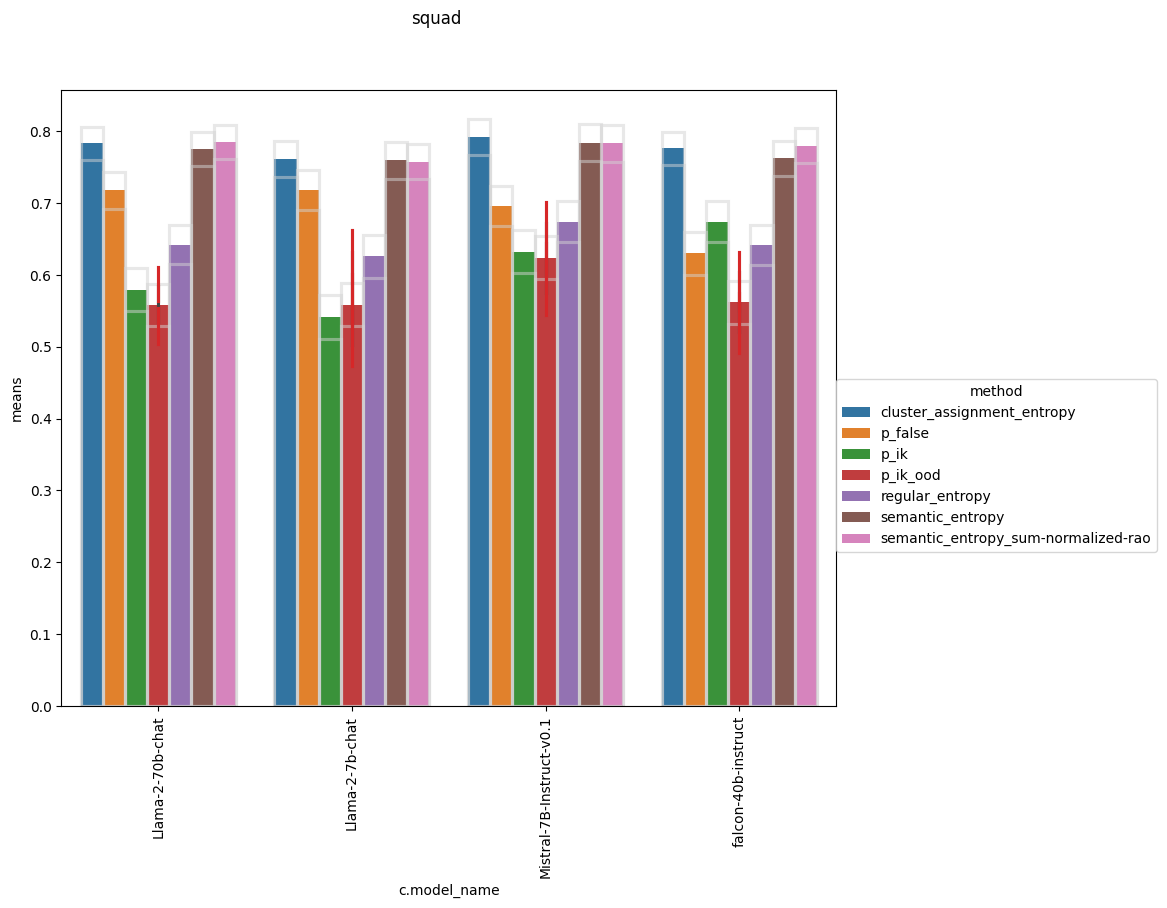

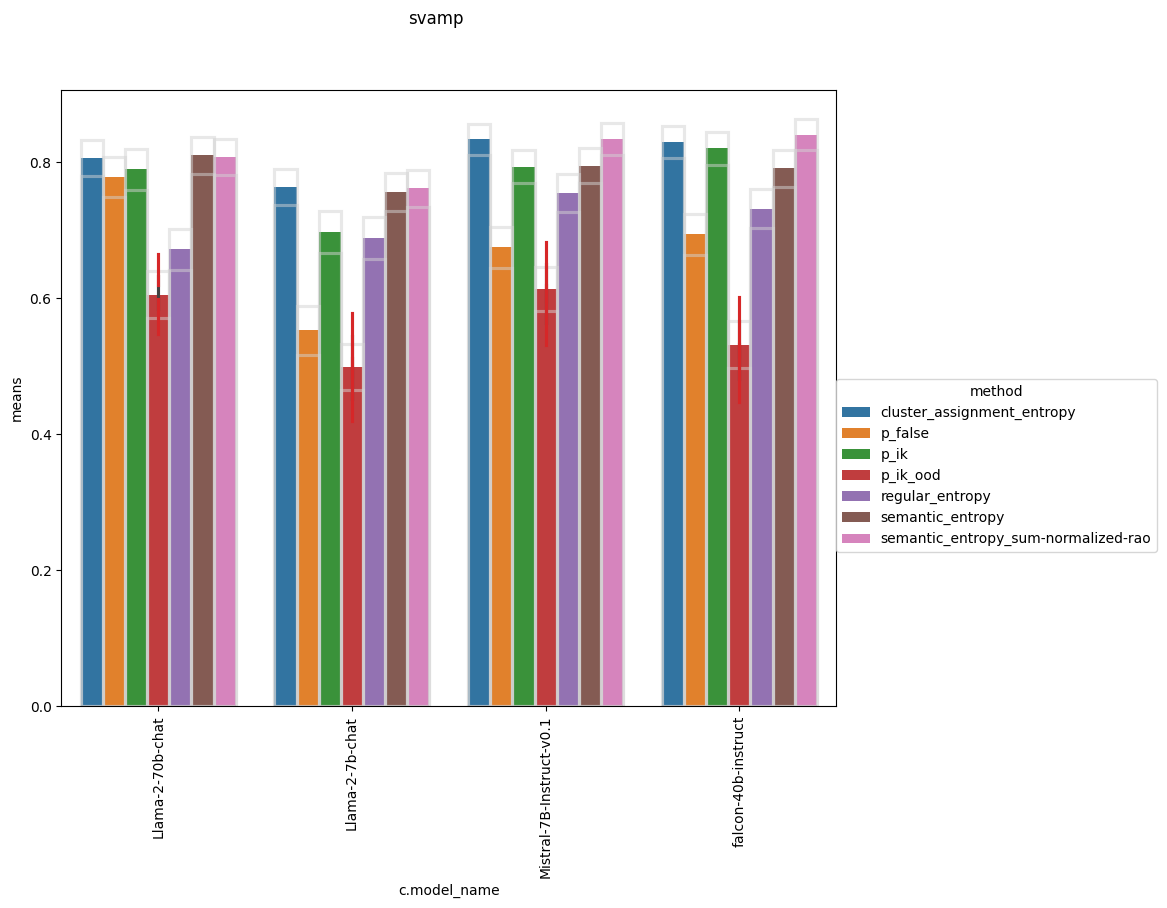

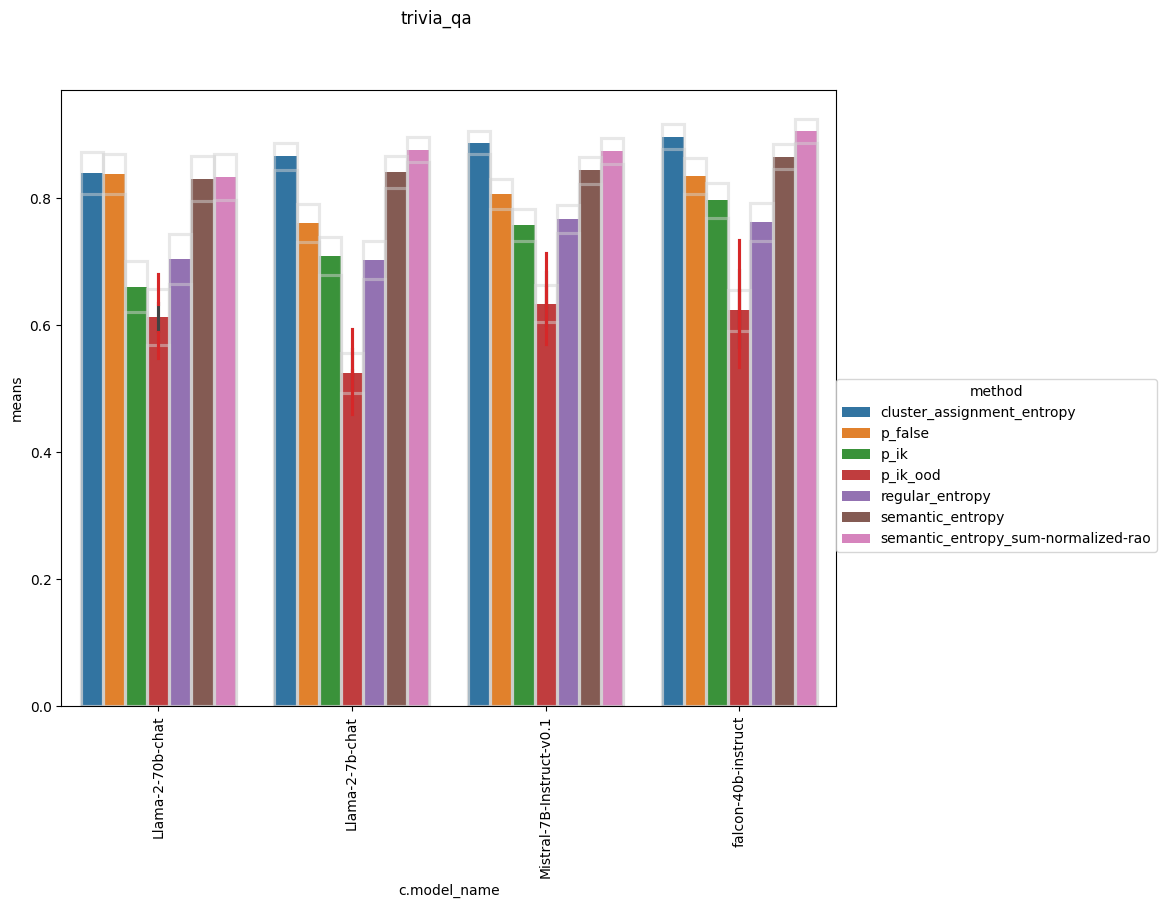

In [705]:
# add average p_ik performance when trained on OOD data
cat_df = pd.concat([pik_all_runs, all_runs])

for dataset, gdf in cat_df.groupby('c.dataset'):

    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[main_methods + ['p_ik_ood']].reset_index(),
        metric='means', x='c.model_name', hue='method',
    )
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.legend(loc=(1, 0.25), title=hue)
/auto/us

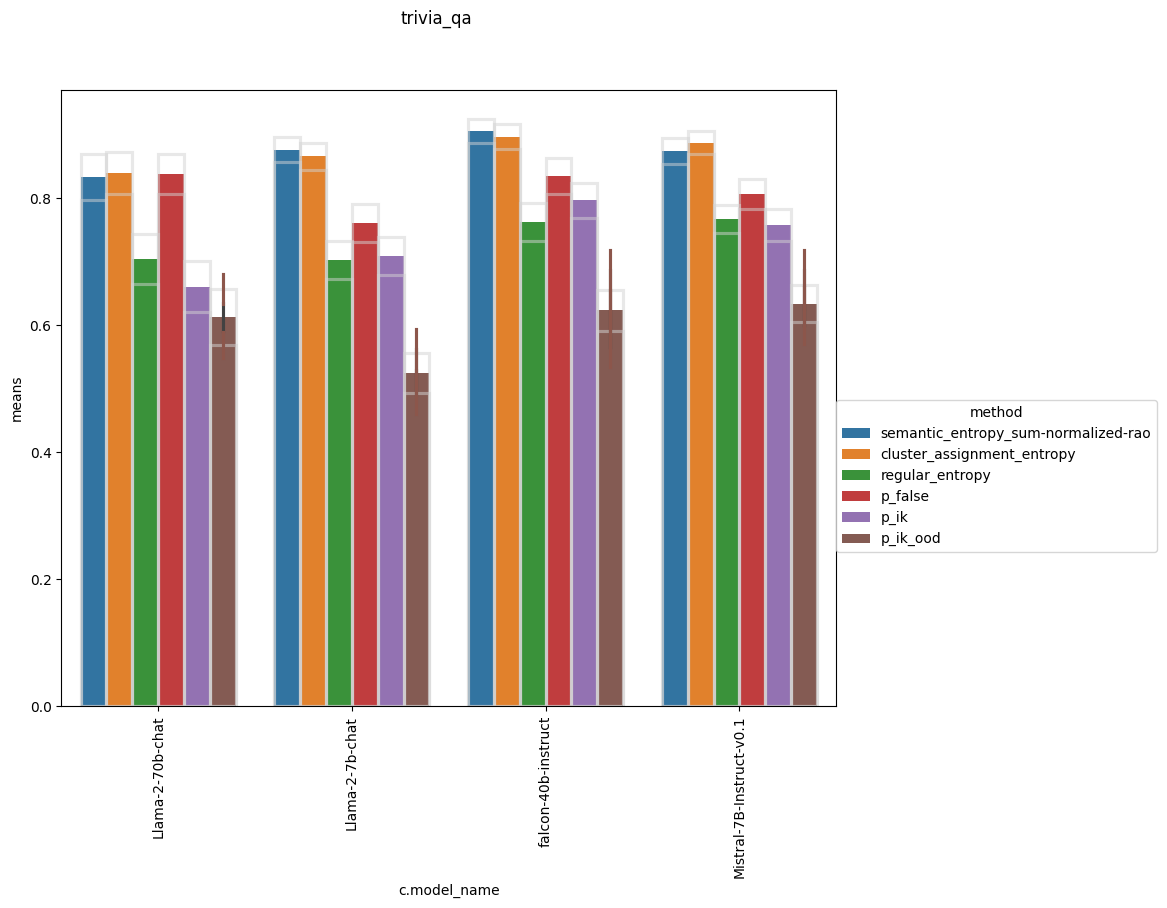

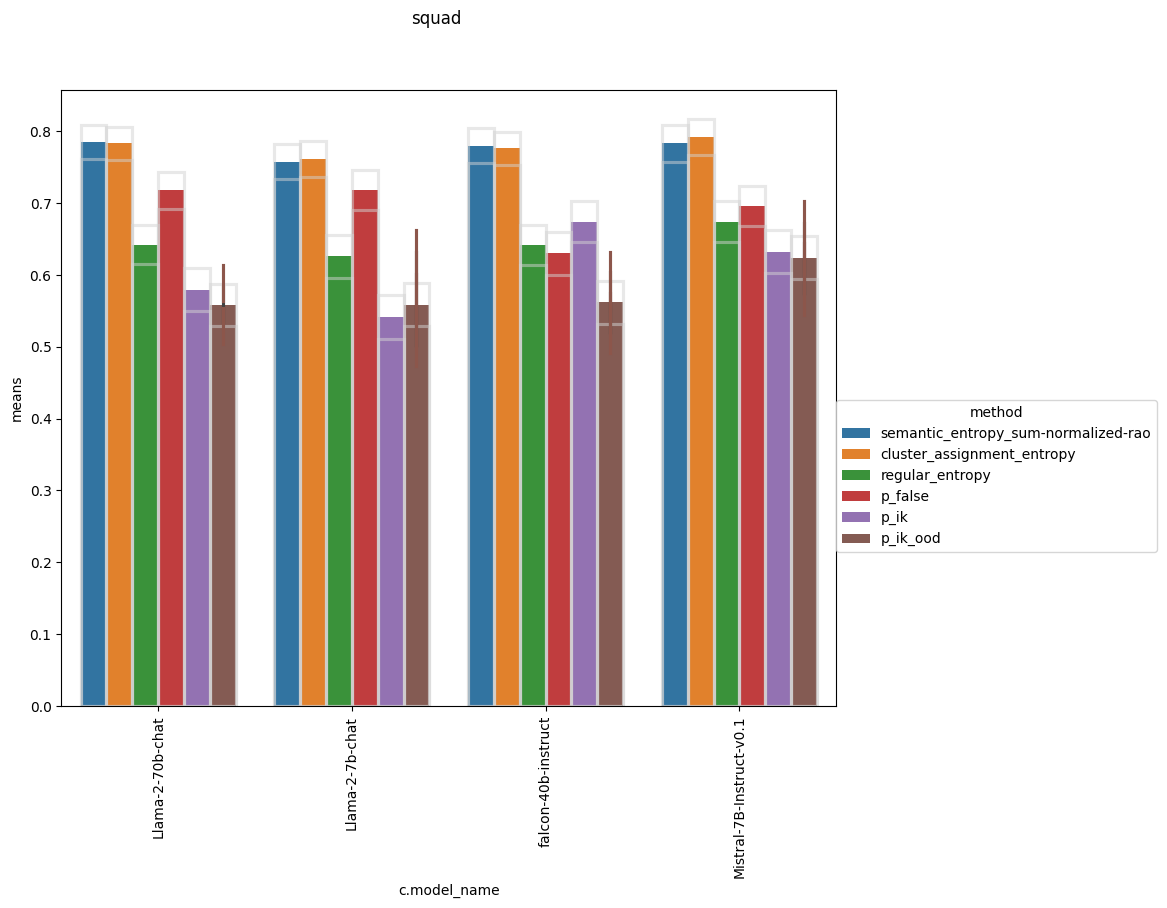

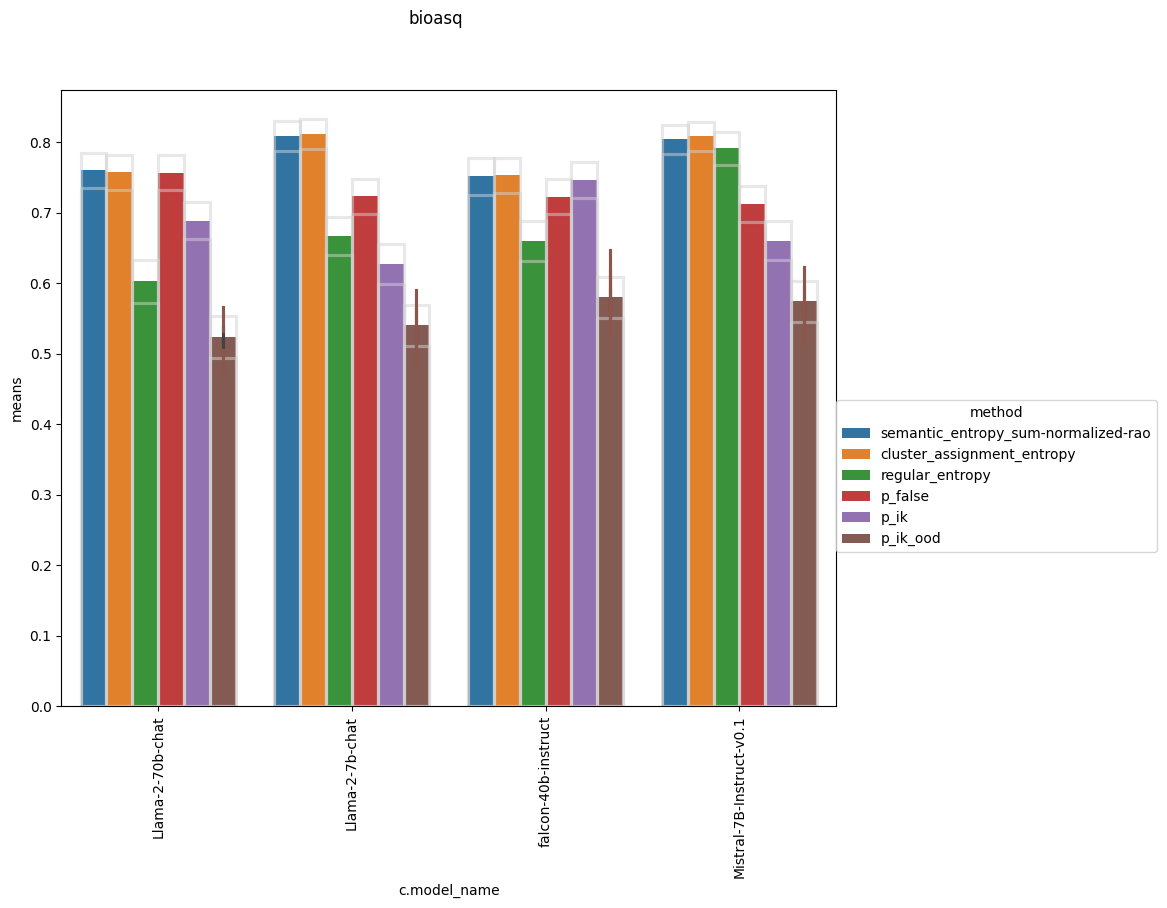

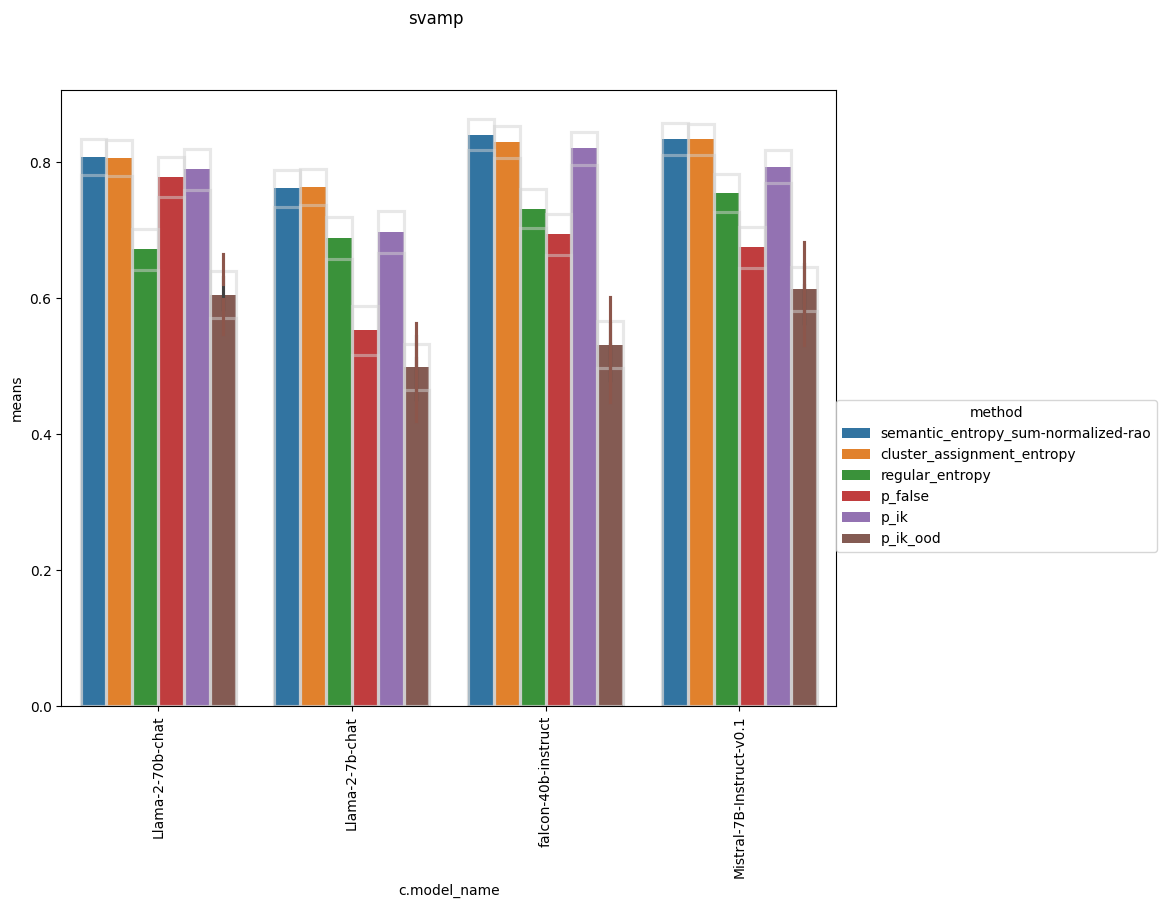

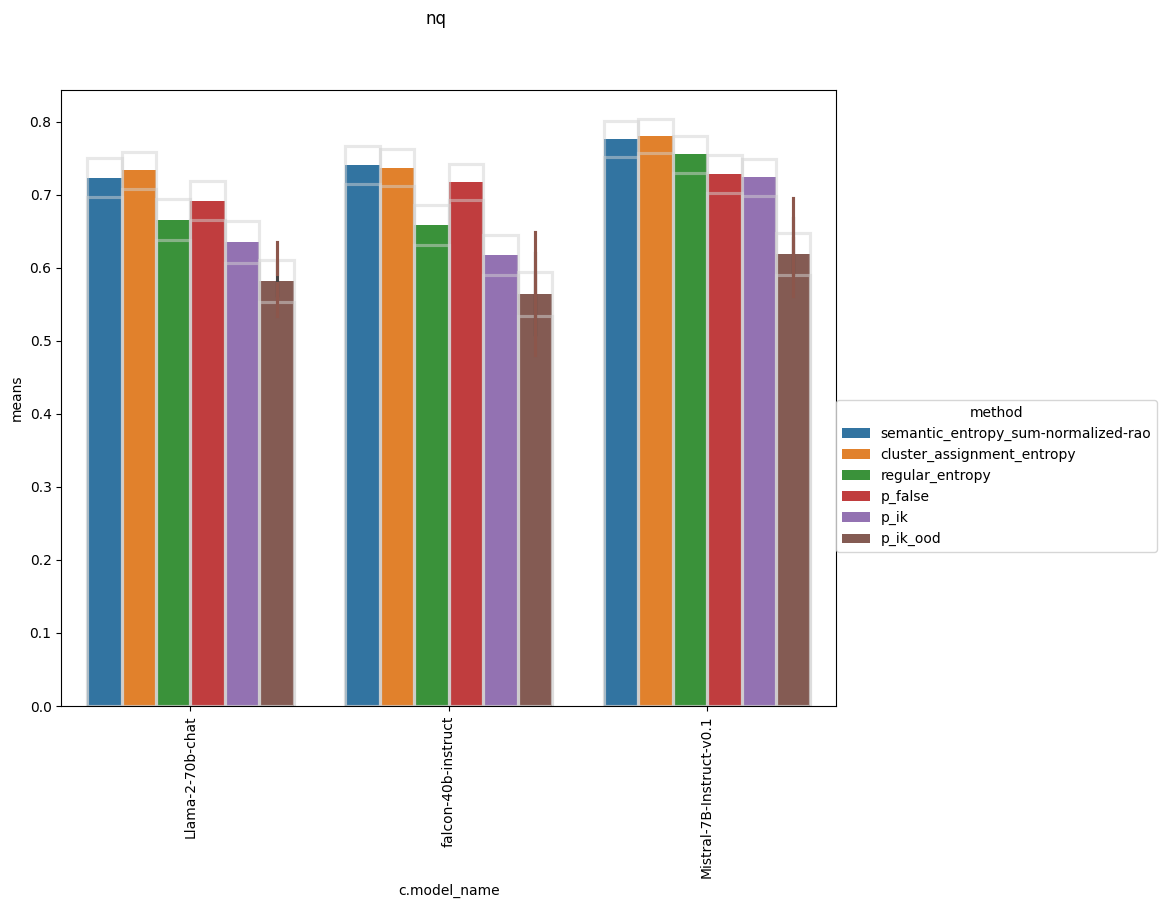

In [634]:
# restrict plot to the datasets/models currently in seb plots
for dataset in ['trivia_qa',  'squad', 'bioasq', 'svamp', 'nq']:
    if dataset == 'nq':
        models = ['Llama-2-70b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1']
    else:
        models = ['Llama-2-70b-chat', 'Llama-2-7b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1']
    gdf = cat_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[models].reset_index()

    methods = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood']
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'].set_index('method').loc[methods].reset_index(),
        metric='means', x='c.model_name', hue='method', with_sort=False)
    plt.gcf().suptitle(dataset)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);
/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:165: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a Fix

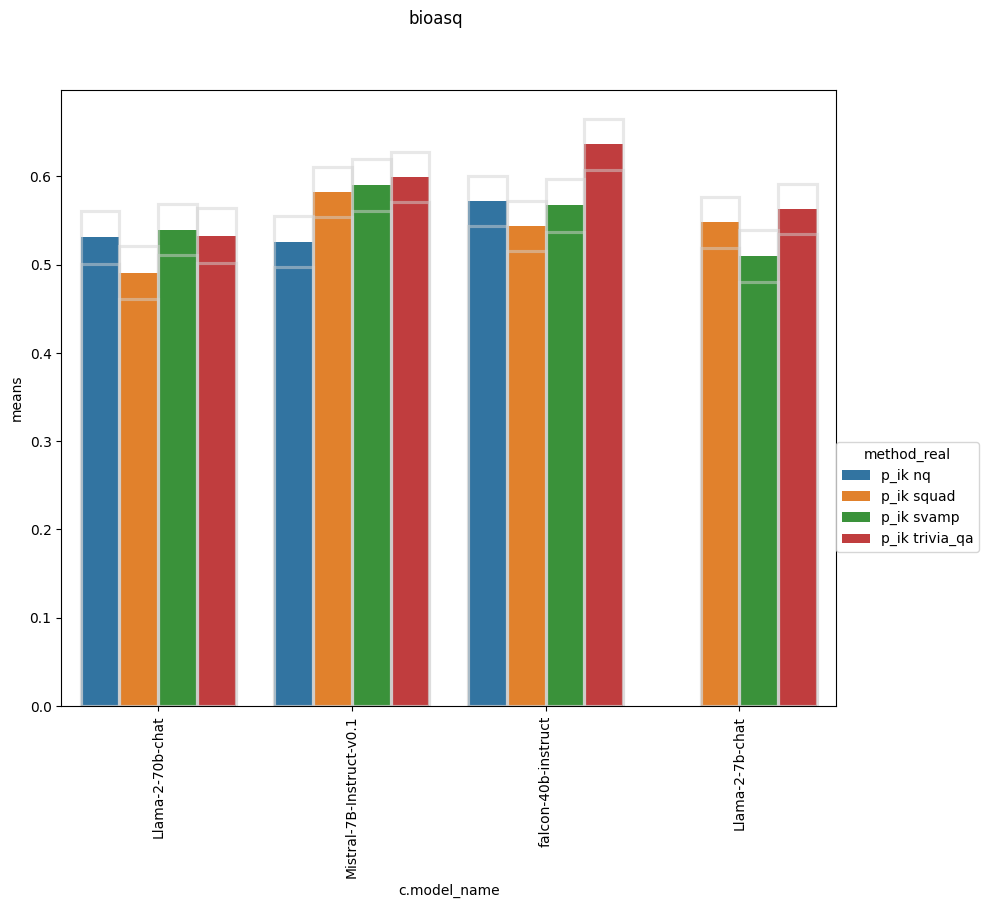

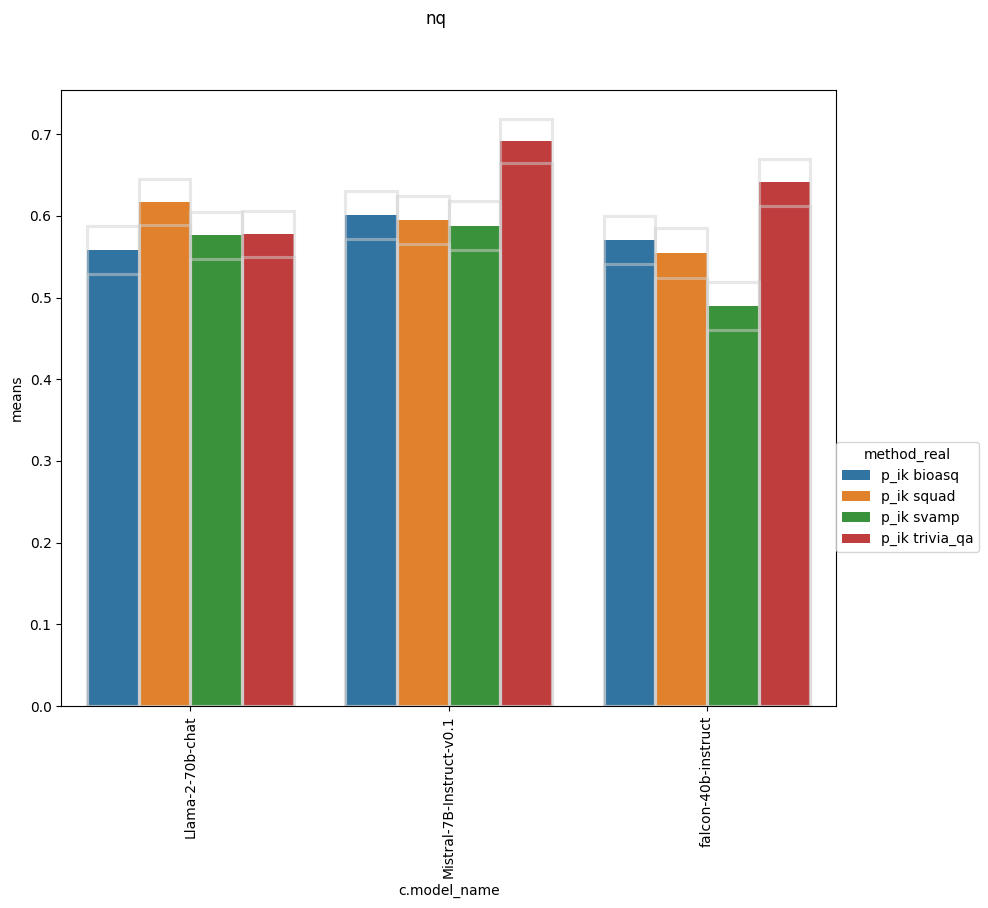

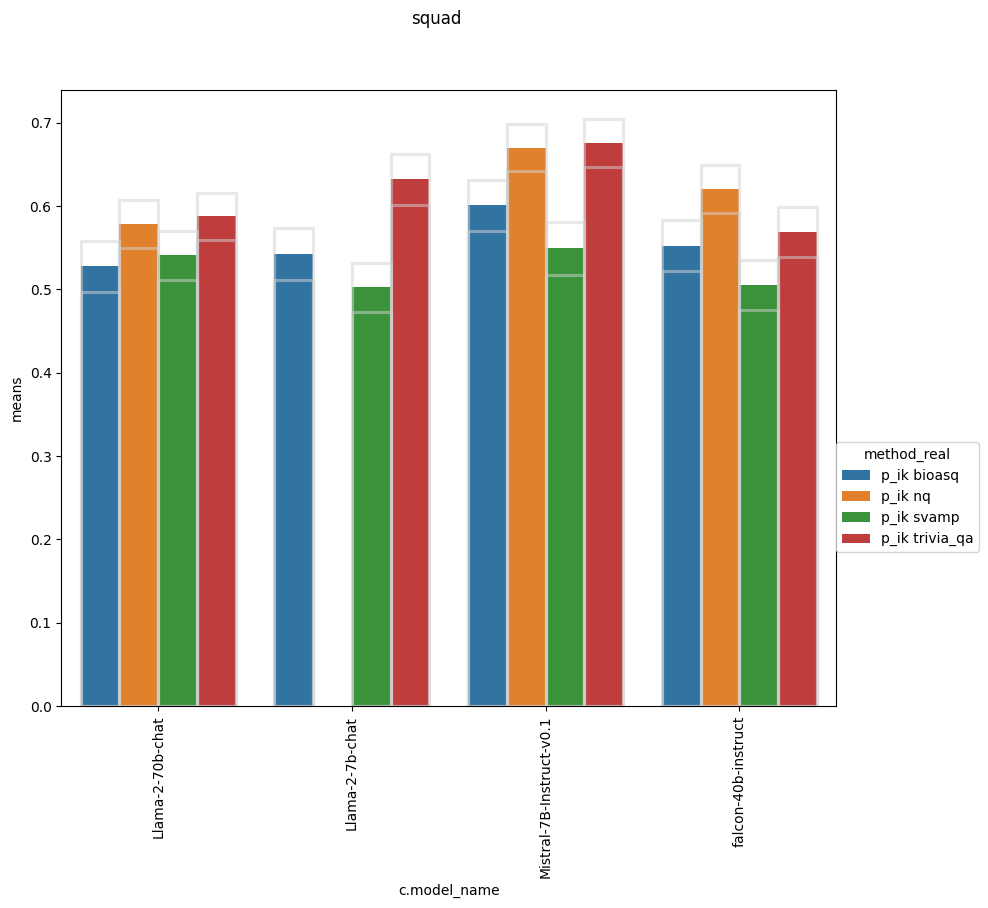

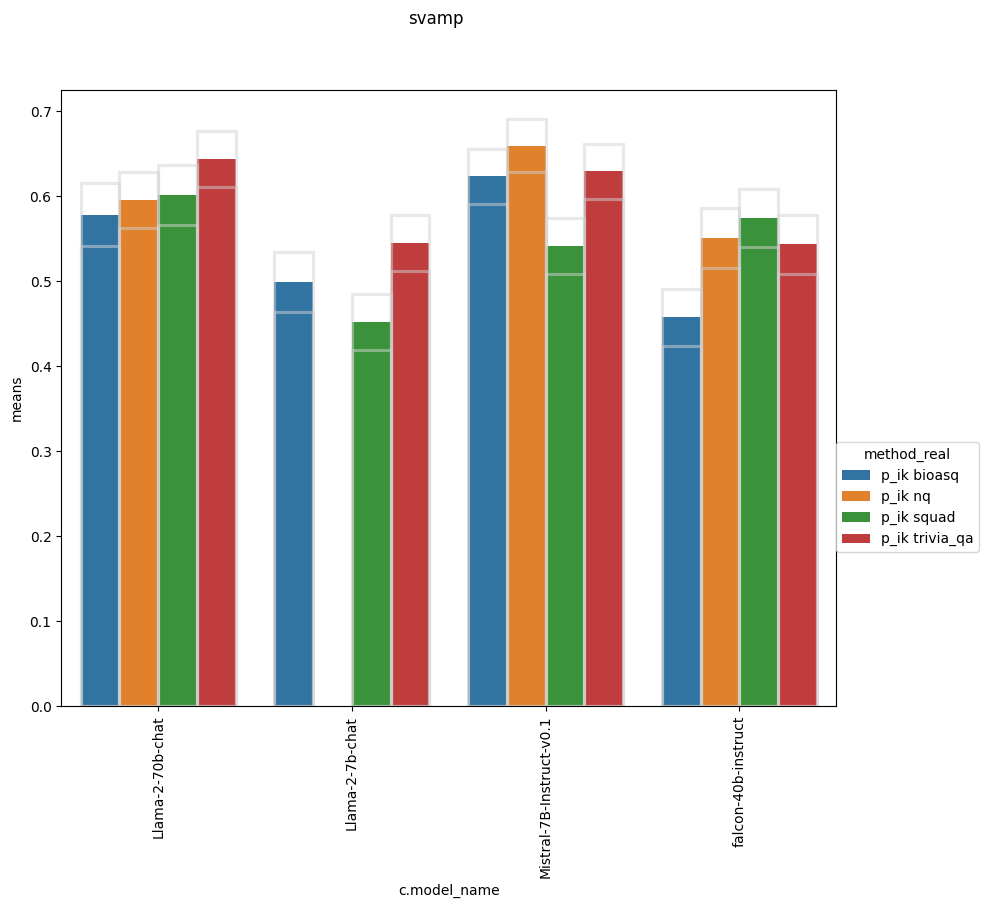

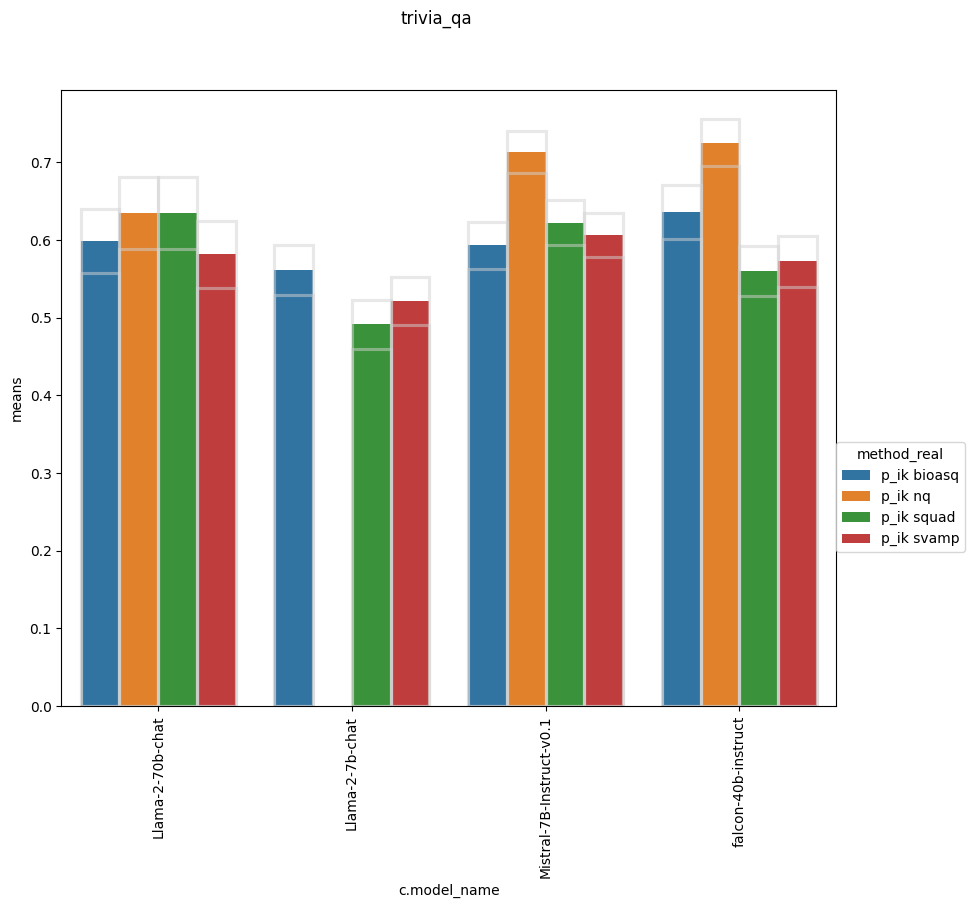

In [554]:
# ood performance separately for p_ik
for dataset, gdf in pik_all_runs.groupby('c.dataset'):
    plot_grouped(
        gdf.set_index('metric').loc['AUROC'],
        metric='means', x='c.model_name', hue='method_real',
    )
    plt.gcf().suptitle(dataset)

In [607]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, METRIC_NAMES, MODEL_NAMES, PRETTY_NAMES
import matplotlib.patches as mpatches


In [652]:
# Full Figure 2 plot for the paper
# We want a massive grid of plots that include AUROC and AU RA C for each dataset (in rows) and model (in columns)

def full_sentence_plot(df, models_in_order=[], datasets_in_order=[], methods_in_order=[], metrics_in_order=[], ylim=None, save_path=None):
    tdf = df.copy()
    n_datasets = len(datasets_in_order)
    n_models = len(models_in_order)
    fig, axs = plt.subplots(n_datasets, n_models, figsize=(2*TEXTWIDTH, 2*TEXTWIDTH), sharex=True, sharey=True)
    for j, model in enumerate(models_in_order):
        for i, dataset in enumerate(datasets_in_order):
            # print(tdf['method'].unique())
            gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & (tdf['metric'].isin(metrics_in_order))].copy()
            # gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & ((tdf['metric'] == 'AUROC') | (tdf['metric'] == 'area_under_thresholded_accuracy'))].copy()
            
            for original_name, new_name in METRIC_NAMES.items():
                gdf.loc[gdf['metric'] == original_name,'metric'] = new_name
            if len(gdf) == 0:
                print(f"Skipping {dataset} {model}")
                continue
            ax = axs[i,j]
            g = sns.barplot(
                    x="metric",       # x variable name
                    y="means",       # y variable name
                    hue="method",  # group variable name
                    data=gdf,     # dataframe to plot
                    ax=ax,
                    hue_order = methods_in_order,
                    palette = COLORS,
                    legend = False,
                    errorbar= None,
            )

            # Crosshatch the p_ik_ood
            n_bars = len(methods_in_order) * len(metrics_in_order)
            idxs_to_edit = np.arange(n_bars-len(metrics_in_order), n_bars, 1)
            for bar_idx, bar in enumerate(g.patches):
                if bar_idx in idxs_to_edit:
                    bar.set_hatch('//')
                    bar.set_facecolor('white')
                    bar.set_edgecolor(COLORS['p_ik_ood'])
            sns.despine()
            if i == n_datasets - 1:
                ax.set_xlabel(MODEL_NAMES[model])
            if j == 0:
                ax.set_ylabel(PRETTY_NAMES[dataset])
            if ylim is None:
                ax.set_ylim(auto=True)
            else:
                ax.set_ylim(*ylim)
            ax.set_axisbelow(True)
            ax.grid(axis='y', linestyle=':', linewidth=.5)
    patches = [mpatches.Patch(color=COLORS[method], label=PRETTY_NAMES[method]) for method in methods_in_order]
    axs[0,2].legend(handles=patches, loc='center', bbox_to_anchor=(-0.1, 1.16), ncols=3, frameon=False)
    if save_path is not None:
        plt.savefig(save_path)
    return True


    

In [707]:
entire_df = pd.concat([all_runs, pik_all_runs], axis=0).reset_index(drop=True)

True

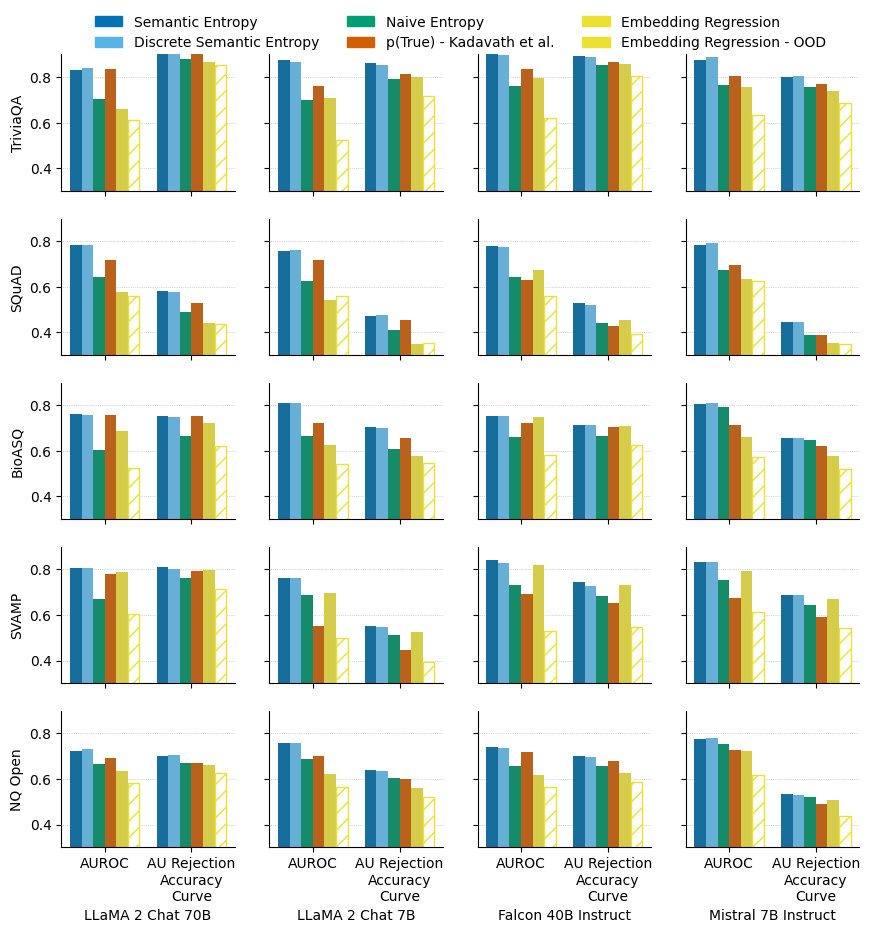

In [713]:
# Plot for Figure 4

full_sentence_plot(entire_df,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'svamp', 'nq'],
                   models_in_order=['Llama-2-70b-chat', 'Llama-2-7b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['AUROC', 'area_under_thresholded_accuracy'],
                   # ylim=(0.0,0.9),
                   ylim=(0.3, 0.9),
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/sentences_main.pdf",
                  )

Skipping nq Llama-2-7b-chat


True

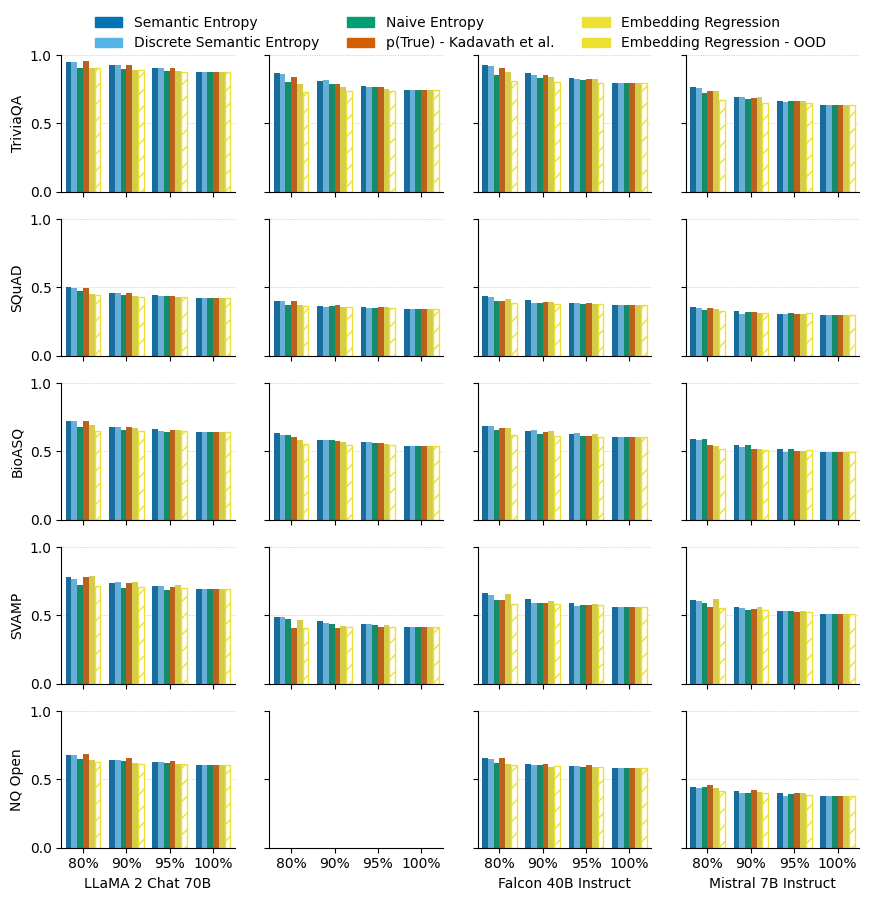

In [625]:
# Backup plot for appendix of all the rejection accuracies

# Plot for Figure 4
full_sentence_plot(entire_df,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'svamp', 'nq'],
                   models_in_order=['Llama-2-70b-chat', 'Llama-2-7b-chat', 'falcon-40b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.8_answer_fraction', 'accuracy_at_0.9_answer_fraction', 'accuracy_at_0.95_answer_fraction', 'accuracy_at_1.0_answer_fraction'],
                   ylim=None,
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentences_rejection_accuracy.pdf")

In [ ]:
def sort_dataframe_by_custom_order(df, column, order):
    """
    Sorts a copy of a DataFrame along a specified column by a specified order of keys.

    Parameters:
    df (pandas.DataFrame): The DataFrame to sort.
    column (str): The column name along which to sort.
    order (list): The specific order of keys for sorting.

    Returns:
    pandas.DataFrame: A sorted copy of the original DataFrame.
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Create a mapping of the order values to their index
    order_mapping = {key: i for i, key in enumerate(order)}

    # Assign a high number for keys not included in the order to sort them at the end
    max_index = len(order)
    df_copy['sort_order'] = df_copy[column].map(lambda x: order_mapping.get(x, max_index))

    # Sort the DataFrame copy by the temporary 'sort_order' column
    sorted_df = df_copy.sort_values('sort_order').drop('sort_order', axis=1)

    return sorted_df


plot the same, but per dataset

(actually, semantic entropy (and variants), are not that bad overall, especially once you start taking smaller models into account (where e.g. p_false oftens sucks))

In [402]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.model_name').mean('means').sort_values('means', ascending=False)

,means,low,high
c.model_name,,,
Mistral-7B-Instruct-v0.1,0.823990,0.801616,0.846364
falcon-40b-instruct,0.803653,0.779970,0.827337
Llama-2-7b-chat,0.801182,0.777839,0.824526
Llama-2-70b-chat,0.781684,0.754098,0.809270


In [403]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp.set_index('method').loc['semantic_entropy_sum-normalized-rao']
tmp.groupby('c.dataset').mean('means').sort_values('means', ascending=False)

,means,low,high
c.dataset,,,
trivia_qa,0.872292,0.848631,0.895952
svamp,0.810605,0.785411,0.835799
bioasq,0.781628,0.758371,0.804886
squad,0.776370,0.751841,0.800900
nq,0.731898,0.705572,0.758225


In [253]:
# note that instead of low/high, should probably compute the standard error over the mean here! (if there are enough categories that we average over!)

tmp = all_runs.set_index('metric').loc['AUROC']

# select main runs (they have deberta entailment and squad metric)
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high
method,,,
cluster_assignment_entropy,0.808887,0.785043,0.832732
semantic_entropy_sum-normalized-rao,0.808647,0.784440,0.832853
semantic_entropy,0.796834,0.771820,0.821847
semantic_entropy_sum-normalized,0.787793,0.762506,0.813080
semantic_entropy_sum_sum-normalized-rao,0.757617,0.731213,0.784021
semantic_entropy_sum_sum-normalized,0.739986,0.712727,0.767246
semantic_entropy_sum,0.730788,0.703236,0.758340
p_false,0.729495,0.701498,0.757492
p_false_fixed,0.729495,0.701450,0.757540


# Analyze length of generations

In [227]:
# read generations from run
all_gens = {}
for wandb_id in runs:

    if eval := configs[wandb_id].get('eval_wandb_runid'):
        # I split up compute_uncertainty for some runs to free up gpus.
        print(f'Taking generate_answers from {eval} instead of compute_uncertainty cfg for {wandb_id}')
        wandb_id = eval

    all_gens[wandb_id] = restore_file(wandb_id, filenames=['validation_generations.pkl'])

Taking generate_answers from g144xlp2 instead of compute_uncertainty cfg for fmqxf9ie
Taking generate_answers from i26x8noh instead of compute_uncertainty cfg for a4nah729


In [231]:
low_temp, high_temp, df = get_length_statistic(all_gens)
df = df.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

df

,temp,wandbid,statistic,value,c.dataset,c.model_name
0,low,grar15m5,mean,153.432500,bioasq,Llama-2-7b-chat
1,low,grar15m5,sem,3.247561,bioasq,Llama-2-7b-chat
2,low,grar15m5,std,64.869989,bioasq,Llama-2-7b-chat
3,low,grar15m5,median,151.500000,bioasq,Llama-2-7b-chat
4,high,grar15m5,mean,155.682250,bioasq,Llama-2-7b-chat
...,...,...,...,...,...,...
99,low,mz7dlrvt,median,40.000000,svamp,falcon-40b-instruct
100,high,mz7dlrvt,mean,54.428000,svamp,falcon-40b-instruct
101,high,mz7dlrvt,sem,0.915392,svamp,falcon-40b-instruct
102,high,mz7dlrvt,std,50.129720,svamp,falcon-40b-instruct


In [232]:
np.concatenate(list(low_temp.values()) + list(high_temp.values())).shape

(62700,)

In [233]:
stats(np.concatenate(list(low_temp.values()) + list(high_temp.values())))

{'mean': 94.77561403508771,
 'sem': 0.28226525999495533,
 'std': 70.6785672904045,
 'median': 79.0}

In [234]:
# this is only correct for mean!!
# stats(df.set_index('statistic').loc['mean']['value'])

In [235]:
# more_detailed results per model and dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    display(gdf.pivot(index=['c.dataset', 'c.model_name'], columns='statistic', values='value')) 

temperature high


statistic                                 mean  median       sem        std
c.dataset c.model_name                                                     
bioasq    Llama-2-7b-chat           155.682250   154.0  1.056253  66.794942
          Mistral-7B-Instruct-v0.1  102.202250    96.0  0.983591  62.199951
          falcon-40b-instruct       124.064750   114.0  1.096878  69.363997
squad     Llama-2-70b-chat          132.881500   114.0  1.237496  78.256351
          Llama-2-7b-chat           123.541000   110.0  1.090283  68.946920
          Mistral-7B-Instruct-v0.1   83.490250    74.0  0.985835  62.341887
svamp     Llama-2-70b-chat           61.252667    52.0  0.692701  37.934454
          Llama-2-7b-chat            59.152667    49.0  0.653455  35.785249
          falcon-40b-instruct        54.428000    43.0  0.915392  50.129720
trivia_qa Llama-2-70b-chat           74.781750    67.0  0.757484  47.901510
          Llama-2-7b-chat            67.093000    61.0  0.713263  45.105076
          Mistral-7B-Instruct-v0.1   38.353250    18.0  0.642521  40.631527
          falcon-40b-instruct        53.685750    47.0  0.718930  45.463447

temperature low


statistic                                 mean  median       sem        std
c.dataset c.model_name                                                     
bioasq    Llama-2-7b-chat           153.432500   151.5  3.247561  64.869989
          Mistral-7B-Instruct-v0.1   92.735000    83.5  2.592427  51.783683
          falcon-40b-instruct       101.865000    95.0  2.316767  46.277389
squad     Llama-2-70b-chat          131.115000   111.0  3.759661  75.099180
          Llama-2-7b-chat           122.955000   110.0  3.443627  68.786394
          Mistral-7B-Instruct-v0.1   80.790000    74.0  2.714514  54.222375
svamp     Llama-2-70b-chat           57.666667    49.0  1.869978  32.334948
          Llama-2-7b-chat            60.203333    50.0  2.057432  35.576331
          falcon-40b-instruct        45.130000    40.0  1.601629  27.694761
trivia_qa Llama-2-70b-chat           72.365000    64.0  2.255123  45.046052
          Llama-2-7b-chat            65.932500    61.0  2.124421  42.435279
          Mistral-7B-Instruct-v0.1   35.060000    16.0  1.859745  37.148370
          falcon-40b-instruct        51.410000    49.0  1.940904  38.769536

In [236]:
# average length per dataset
for name, gdf in df.groupby('temp'):
    print('temperature', name)
    gdf = gdf.set_index('statistic').loc['mean'].reset_index()
    display(gdf.groupby('c.dataset').mean('value'))


temperature high


,value
c.dataset,
bioasq,127.316417
squad,113.304250
svamp,58.277778
trivia_qa,58.478437


temperature low


,value
c.dataset,
bioasq,116.010833
squad,111.620000
svamp,54.333333
trivia_qa,56.191875


In [546]:
# average length per model
for name, gdf in df.groupby('temp'):
    print(name)
    gdf = gdf.set_index('statistic').loc['mean']
    display(gdf.groupby('c.model_name').mean('value'))

high


,value
c.model_name,
Llama-2-70b-chat,89.638639
Llama-2-7b-chat,101.367229
Mistral-7B-Instruct-v0.1,74.681917
falcon-40b-instruct,77.392833


low


,value
c.model_name,
Llama-2-70b-chat,87.048889
Llama-2-7b-chat,100.630833
Mistral-7B-Instruct-v0.1,69.528333
falcon-40b-instruct,66.135000


# Cluster distribution 

In [238]:
uncertainties = {}
for wandb_id in runs:
    uncertainties[wandb_id] = restore_file(wandb_id, filenames=['uncertainty_measures.pkl'])

In [239]:
num_ids = {}
for wandbid, unc in uncertainties.items():
    unc = unc[0]
    num_ids[wandbid] = np.array([len(np.unique(s)) for s in np.array(unc['semantic_ids'])])

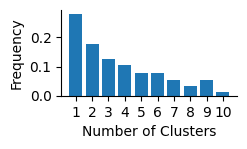

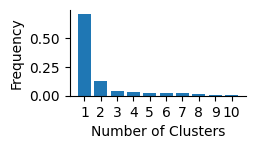

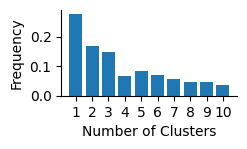

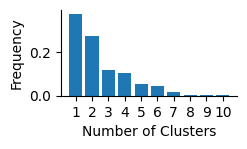

In [544]:
def plot_clusters(model, dataset, save_path=None):
    fig, ax = plt.subplots(1,1,figsize=(TEXTWIDTH / 2, TEXTWIDTH / 2 / GOLDEN_RATIO))
    wid = arg_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
    uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
    cluster_frequencies = count_values / sum(count_values)
    ax.bar(uniq_counts, cluster_frequencies)
    ax.set_xticks(uniq_counts)
    ax.set_xlabel('Number of Clusters')
    ax.set_ylabel('Frequency')
    sns.despine()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)

for dataset in ["bioasq", "trivia_qa", "squad","svamp"]:
    plot_clusters('Llama-2-70b-chat', dataset, save_path=f"/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_sentences_n_clusters_{dataset}.pdf")

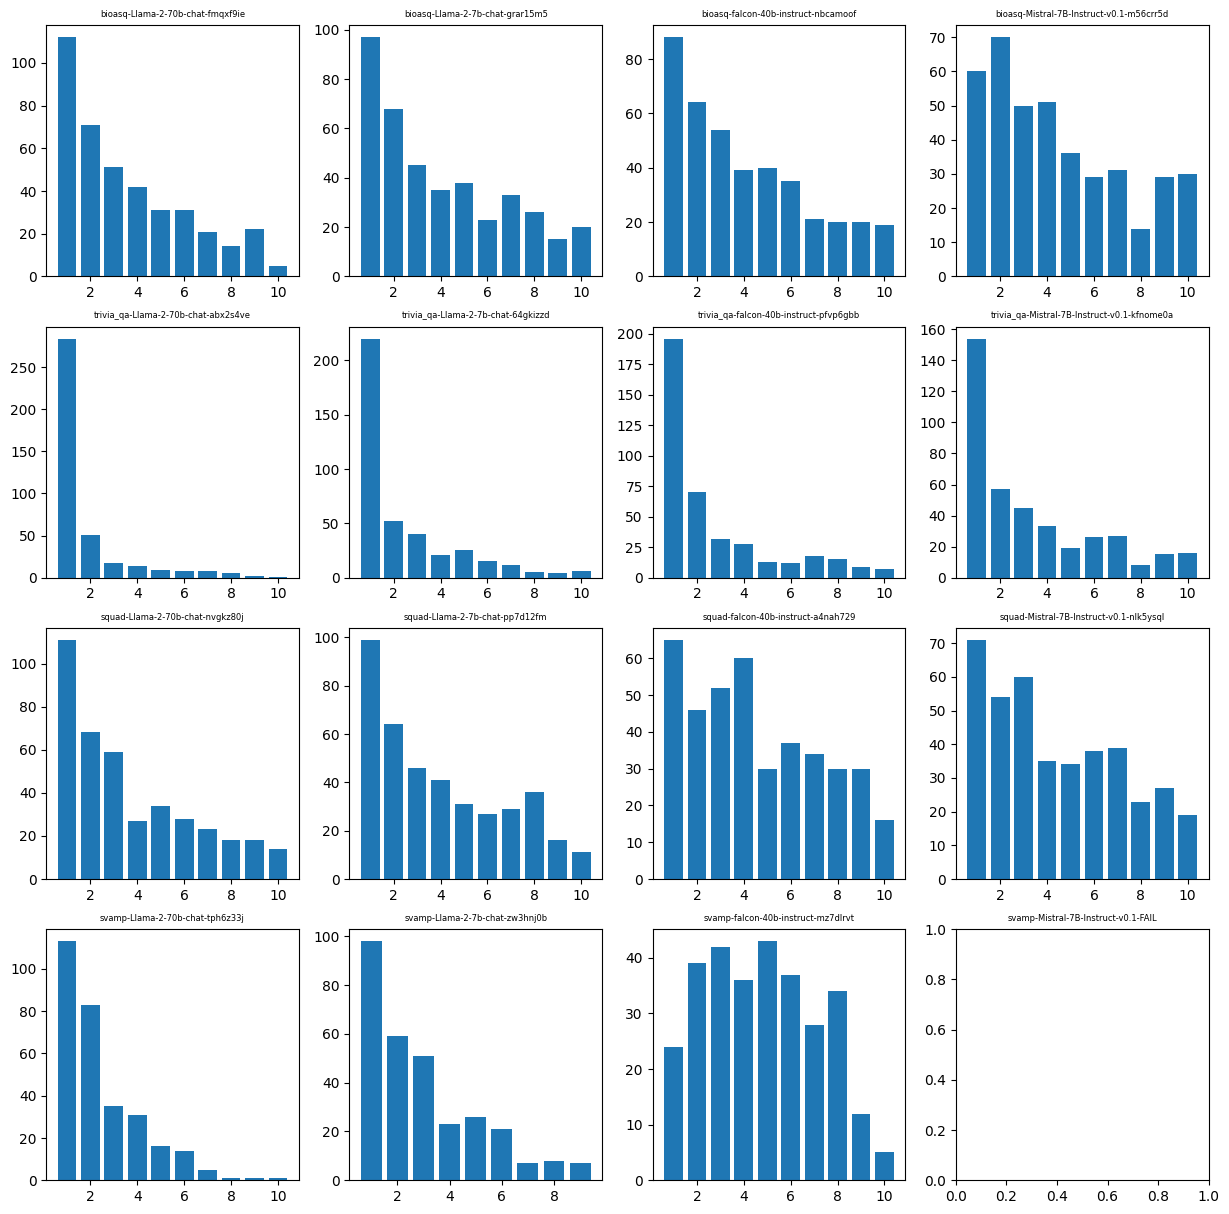

In [241]:
fig, axes_2d = plt.subplots(*arg_df[['c.dataset', 'c.model_name']].nunique().values, figsize=(15, 15))

for axes, dataset in zip(axes_2d, arg_df['c.dataset'].unique()):
    for ax, model in zip(axes, arg_df['c.model_name'].unique()):
        try:
            wid = arg_df.set_index('c.dataset').loc[dataset].set_index('c.model_name').loc[model]['wandbid']
            ax.set_title(f'{dataset}-{model}-{wid}', fontsize=6)
            uniq_counts, count_values = np.unique(num_ids[wid], return_counts=True)
            ax.bar(uniq_counts, count_values)
        except:    
            ax.set_title(f'{dataset}-{model}-FAIL', fontsize=6)
    


In [242]:
cdf = get_cluster_stats(num_ids)
cdf = cdf.merge(arg_df[['wandbid', 'c.dataset', 'c.model_name']], on='wandbid')

cdf

,wandbid,statistic,value,c.dataset,c.model_name
0,fmqxf9ie,mean,3.557500,bioasq,Llama-2-70b-chat
1,fmqxf9ie,sem,0.126716,bioasq,Llama-2-70b-chat
2,fmqxf9ie,std,2.531145,bioasq,Llama-2-70b-chat
3,fmqxf9ie,median,3.000000,bioasq,Llama-2-70b-chat
4,grar15m5,mean,4.025000,bioasq,Llama-2-7b-chat
5,grar15m5,sem,0.139991,bioasq,Llama-2-7b-chat
6,grar15m5,std,2.796315,bioasq,Llama-2-7b-chat
7,grar15m5,median,3.000000,bioasq,Llama-2-7b-chat
8,nbcamoof,mean,4.052500,bioasq,falcon-40b-instruct
9,nbcamoof,sem,0.136504,bioasq,falcon-40b-instruct


In [243]:
# overall stats
stats(np.concatenate(list(num_ids.values())))

{'mean': 3.5605263157894735,
 'sem': 0.03520733291400443,
 'std': 2.6578621675961784,
 'median': 3.0}

In [244]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.model_name').mean('value'))

,value
c.model_name,
Llama-2-70b-chat,2.872917
Llama-2-7b-chat,3.346667
Mistral-7B-Instruct-v0.1,4.099167
falcon-40b-instruct,4.028333


In [245]:
display(cdf.set_index('statistic').loc['mean'].groupby('c.dataset').mean('value'))

,value
c.dataset,
bioasq,4.032500
squad,4.180000
svamp,3.402222
trivia_qa,2.558125


# Create run scripts for p_ik ood eval

In [440]:
cmd = 'sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py '
cmd += '--eval_wandb_runid={eval} --train_wandb_runid={train} --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood'

In [663]:
target = 'Llama-2-7b-chat'
for model, gdf in arg_df.groupby('c.model_name'):
    print(f'# model: {model}')
    if model != target:
        continue
    for ds1, gdf1 in gdf.groupby('c.dataset'):
        assert len(gdf1) == 1
        for ds2, gdf2 in gdf.groupby('c.dataset'):
            assert len(gdf2) == 1

            if ds1 == ds2:
                continue

            if (ds1 == 'nq') or (ds2 == 'nq'):            
                wandbid1 = gdf1['wandbid'].values[0]
                wandbid2 = gdf2['wandbid'].values[0]
                
                print(cmd.format(eval=wandbid1, train=wandbid2) + f' # {ds1}, {ds2}')

# model: Llama-2-70b-chat
# model: Llama-2-7b-chat
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=grar15m5 --train_wandb_runid=86mu0ogq --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood # bioasq, nq
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_wandb_runid=grar15m5 --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood # nq, bioasq
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_wandb_runid=pp7d12fm --no-compute_predictive_entropy --experiment_lot=231201_ptrue_ood # nq, squad
sbatch --cpus-per-task=4 slurm/run_uncertainty_estimates.sh python semantic_uncertainty/compute_uncertainty_measures.py --eval_wandb_runid=86mu0ogq --train_wandb_runid=zw3hnj0b --no-

In [ ]:
target = 
model = 'Llama-2-7b-chat'
gdf = arg_df.set_index('c.model_name').loc[model]
print(f'# model: {model}')
for ds1, gdf1 in gdf.groupby('c.dataset'):
    assert len(gdf1) == 1
        for ds2, gdf2 in gdf.groupby('c.dataset'):
            assert len(gdf2) == 1

            if ds1 == ds2:
                continue

            if (ds1 == 'nq') or (ds2 == 'nq'):
                wandbid1 = gdf1['wandbid'].values[0]
                wandbid2 = gdf2['wandbid'].values[0]
                
                print(cmd.format(eval=wandbid1, train=wandbid2))

# Check on p_ik ood runs

In [683]:
run.description

'sweet-forest-606\nslurm_id: 172813, experiment_lot: 231201_ptrue_ood'

In [ ]:
import wandb

api = wandb.Api()
api_runs = api.runs('goatml/semantic_uncertainty')



In [696]:
configs = {}
for run in api_runs[:600]:
    finished = run.state == 'finished'
    lot = run.description.endswith('231201_ptrue_ood')
    if lot and finished:
        configs[run.id] = run.config
        configs[run.id]['state'] = run.state
        configs[run.id]['slurmid'] = run.notes.split(': ')[1].split(',')[0]


In [697]:
args = ['state', 'slurmid', 'dataset', 'model_name', 'ood_training_set', 'train_wandb_runid', 'eval_wandb_runid']
# args = ['state', 'slurmid', 'dataset', 'train_wandb_runid', 'eval_wandb_runid']

tmp_arg_df, _, _ = get_arg_df(configs)

tmp_arg_df['c.model_name'] = tmp_arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])

with pd.option_context('display.max_rows', None):
    tmp = tmp_arg_df
    display(tmp.set_index('c.state').loc['finished']) #need display to show the dataframe when using with in jupyter


,wandbid,c.slurmid,c.dataset,c.model_name,c.ood_training_set,c.train_wandb_runid,c.eval_wandb_runid,UNIQ-c.dataset-c.model_name-c.ood_training_set-c.train_wandb_runid-c.eval_wandb_runid
c.state,,,,,,,,
finished,ndiepky2,173142,svamp,Llama-2-7b-chat,nq,86mu0ogq,zw3hnj0b,svamp-Llama-2-7b-chat-8bit-nq-86mu0ogq-zw3hnj0b
finished,3xppsi0w,173141,squad,Llama-2-7b-chat,nq,86mu0ogq,pp7d12fm,squad-Llama-2-7b-chat-nq-86mu0ogq-pp7d12fm
finished,ljcrh54n,173137,nq,Llama-2-7b-chat,bioasq,grar15m5,86mu0ogq,nq-Llama-2-7b-chat-8bit-bioasq-grar15m5-86mu0ogq
finished,jgc2thy5,173138,nq,Llama-2-7b-chat,squad,pp7d12fm,86mu0ogq,nq-Llama-2-7b-chat-8bit-squad-pp7d12fm-86mu0ogq
finished,lciwu77a,173140,nq,Llama-2-7b-chat,trivia_qa,64gkizzd,86mu0ogq,nq-Llama-2-7b-chat-8bit-trivia_qa-64gkizzd-86m...
finished,92reb6vl,173143,trivia_qa,Llama-2-7b-chat,nq,86mu0ogq,64gkizzd,trivia_qa-Llama-2-7b-chat-nq-86mu0ogq-64gkizzd
finished,dy73gfru,173136,bioasq,Llama-2-7b-chat,nq,86mu0ogq,grar15m5,bioasq-Llama-2-7b-chat-nq-86mu0ogq-grar15m5
finished,hu8cexu0,173139,nq,Llama-2-7b-chat,svamp,zw3hnj0b,86mu0ogq,nq-Llama-2-7b-chat-8bit-svamp-zw3hnj0b-86mu0ogq
finished,ueysytnh,172837,svamp,falcon-40b-instruct,nq,ab1d15w8,mz7dlrvt,svamp-falcon-40b-instruct-nq-ab1d15w8-mz7dlrvt


In [698]:
for name, gdf in tmp.groupby(['c.train_wandb_runid', 'c.eval_wandb_runid']):
    if len(gdf) > 1:
        print(name)
        display(gdf)

for model_name, gdf in tmp_arg_df.groupby('c.model_name'):

    print(model_name)
    display(gdf.pivot(index='c.dataset', columns='c.ood_training_set', values='wandbid'))

Llama-2-70b-chat


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,fc4j2r3i,e0imxyab,6rty54ha,ig4qamip
nq,yqefd5tw,NaN,l9uonw9o,5dxgi7l4,7mkmiodg
squad,t39a8www,h473y96f,NaN,5bumj7c2,vik61pbd
svamp,b4mm06ws,77h3tvmd,jij6xvq6,NaN,j6mc86id
trivia_qa,iztfq74f,r5jrwa0p,ektr1wx1,5auzcurn,NaN


Llama-2-7b-chat


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,dy73gfru,1pcia04j,bh9uaw62,bvpw98ih
nq,ljcrh54n,NaN,jgc2thy5,hu8cexu0,lciwu77a
squad,pbk4bb3v,3xppsi0w,NaN,ue0gu578,p9cad6z3
svamp,qmb1uu6c,ndiepky2,mj98zcis,NaN,v1uuwmni
trivia_qa,22n8akov,92reb6vl,s2b3dq5z,ix8o3ar9,NaN


Mistral-7B-Instruct-v0.1


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,78ubflxu,28is5g4g,86xnaea5,vasvluw9
nq,64rh8qyb,NaN,wa4xw7dn,c8p7ona4,xnwy93zh
squad,wqk3twti,akbz2zit,NaN,lzwbjj0u,sd6mwmt4
svamp,tojydb0d,64mwf45o,xw2oxw14,NaN,bqhpmgd5
trivia_qa,sk7xx6a9,g7w0saqf,vkrfbq14,e7u6a42p,NaN


falcon-40b-instruct


c.ood_training_set,bioasq,nq,squad,svamp,trivia_qa
c.dataset,,,,,
bioasq,NaN,70v00ze7,8qx4w6pu,itt028az,k2y3iypk
nq,jehdmd18,NaN,g0563a58,50kln4yq,0929rm33
squad,5ytf3m50,gnbhhmbp,NaN,jimxzgwm,2c6skk6g
svamp,szxwvi88,ueysytnh,si8o1o3o,NaN,39iaj5ss
trivia_qa,588kp7t1,rvvamd9u,ltjjp3jv,wazba7ok,NaN


In [701]:
# t = tmp_arg_df
# {w: f'{m}-{d}-{o}' for w, m, d, o in zip(t['wandbid'], t['c.model_name'], t['c.dataset'], t['c.ood_training_set'])}

{'ndiepky2': 'Llama-2-7b-chat-svamp-nq',
 '3xppsi0w': 'Llama-2-7b-chat-squad-nq',
 'ljcrh54n': 'Llama-2-7b-chat-nq-bioasq',
 'jgc2thy5': 'Llama-2-7b-chat-nq-squad',
 'lciwu77a': 'Llama-2-7b-chat-nq-trivia_qa',
 '92reb6vl': 'Llama-2-7b-chat-trivia_qa-nq',
 'dy73gfru': 'Llama-2-7b-chat-bioasq-nq',
 'hu8cexu0': 'Llama-2-7b-chat-nq-svamp',
 'ueysytnh': 'falcon-40b-instruct-svamp-nq',
 'si8o1o3o': 'falcon-40b-instruct-svamp-squad',
 'itt028az': 'falcon-40b-instruct-bioasq-svamp',
 'jimxzgwm': 'falcon-40b-instruct-squad-svamp',
 '8qx4w6pu': 'falcon-40b-instruct-bioasq-squad',
 'szxwvi88': 'falcon-40b-instruct-svamp-bioasq',
 '70v00ze7': 'falcon-40b-instruct-bioasq-nq',
 'gnbhhmbp': 'falcon-40b-instruct-squad-nq',
 'vkrfbq14': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '2c6skk6g': 'falcon-40b-instruct-squad-trivia_qa',
 'e7u6a42p': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 'wqk3twti': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 '0929rm3

In [702]:
t = tmp_arg_df
{w: f'{m}-{d}-{o}' for w, m, d, o in zip(t['wandbid'], t['c.model_name'], t['c.dataset'], t['c.ood_training_set']) if 'nq' in d}

{'ljcrh54n': 'Llama-2-7b-chat-nq-bioasq',
 'jgc2thy5': 'Llama-2-7b-chat-nq-squad',
 'lciwu77a': 'Llama-2-7b-chat-nq-trivia_qa',
 'hu8cexu0': 'Llama-2-7b-chat-nq-svamp',
 'xnwy93zh': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '0929rm33': 'falcon-40b-instruct-nq-trivia_qa',
 'wa4xw7dn': 'Mistral-7B-Instruct-v0.1-nq-squad',
 'jehdmd18': 'falcon-40b-instruct-nq-bioasq',
 '64rh8qyb': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'g0563a58': 'falcon-40b-instruct-nq-squad',
 'c8p7ona4': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 '50kln4yq': 'falcon-40b-instruct-nq-svamp',
 '5dxgi7l4': 'Llama-2-70b-chat-nq-svamp',
 'yqefd5tw': 'Llama-2-70b-chat-nq-bioasq',
 '7mkmiodg': 'Llama-2-70b-chat-nq-trivia_qa',
 'l9uonw9o': 'Llama-2-70b-chat-nq-squad'}